## **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid", font_scale=1.5)
import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_predict

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import  confusion_matrix, classification_report,roc_auc_score,roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score

## **📩 Data Representation**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
non_fraud_duplicates = df[df["Class"] == 0].duplicated().sum()

print(f"Count of Duplicates in Non Fraud Class = {non_fraud_duplicates}")

Count of Duplicates in Non Fraud Class = 1062


In [8]:
fraud_duplicates = df[df["Class"] == 1].duplicated().sum()

print(f"Count of Duplicates in Fraud Class = {fraud_duplicates}")

Count of Duplicates in Fraud Class = 19


In [9]:

print(f"Total Number of Duplicates = {df.duplicated().sum()}")

Total Number of Duplicates = 1081


In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.duplicated().sum()

np.int64(0)

## **📊 Exploratory Data Analysis-(EDA)**

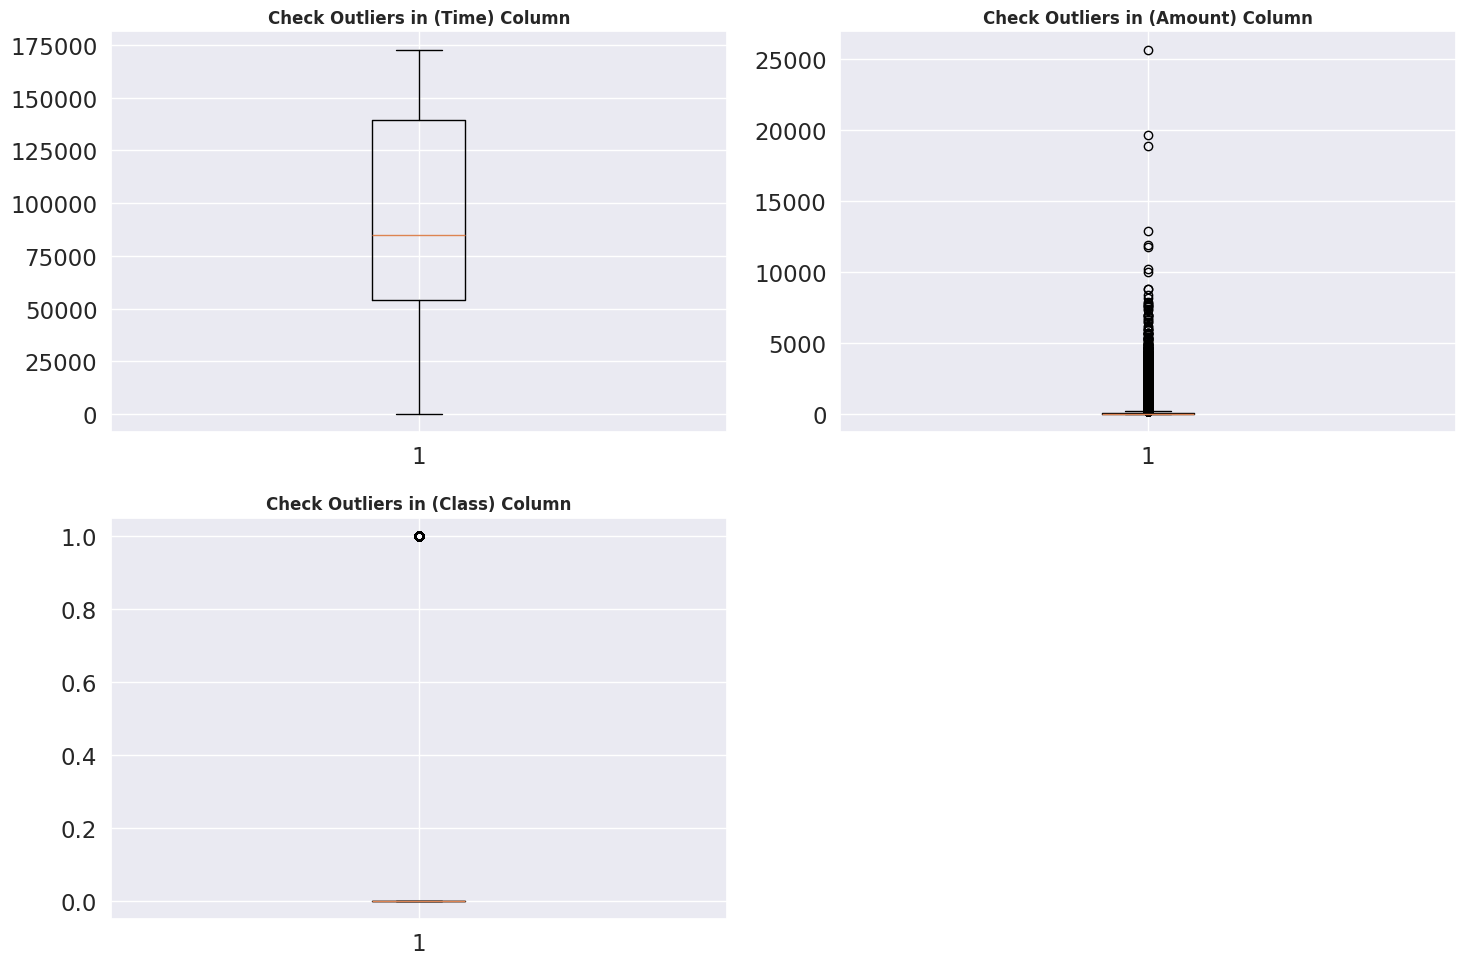

In [12]:
check_outlier = ['Time', 'Amount', 'Class']


plt.figure(figsize=(15,10))
for ind, val in enumerate(check_outlier):
    plt.subplot(2,2, ind+1)
    plt.boxplot(df[val] )
    plt.title(f"Check Outliers in ({val}) Column", fontweight="black", size=12)

plt.tight_layout()
plt.show()


In [13]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

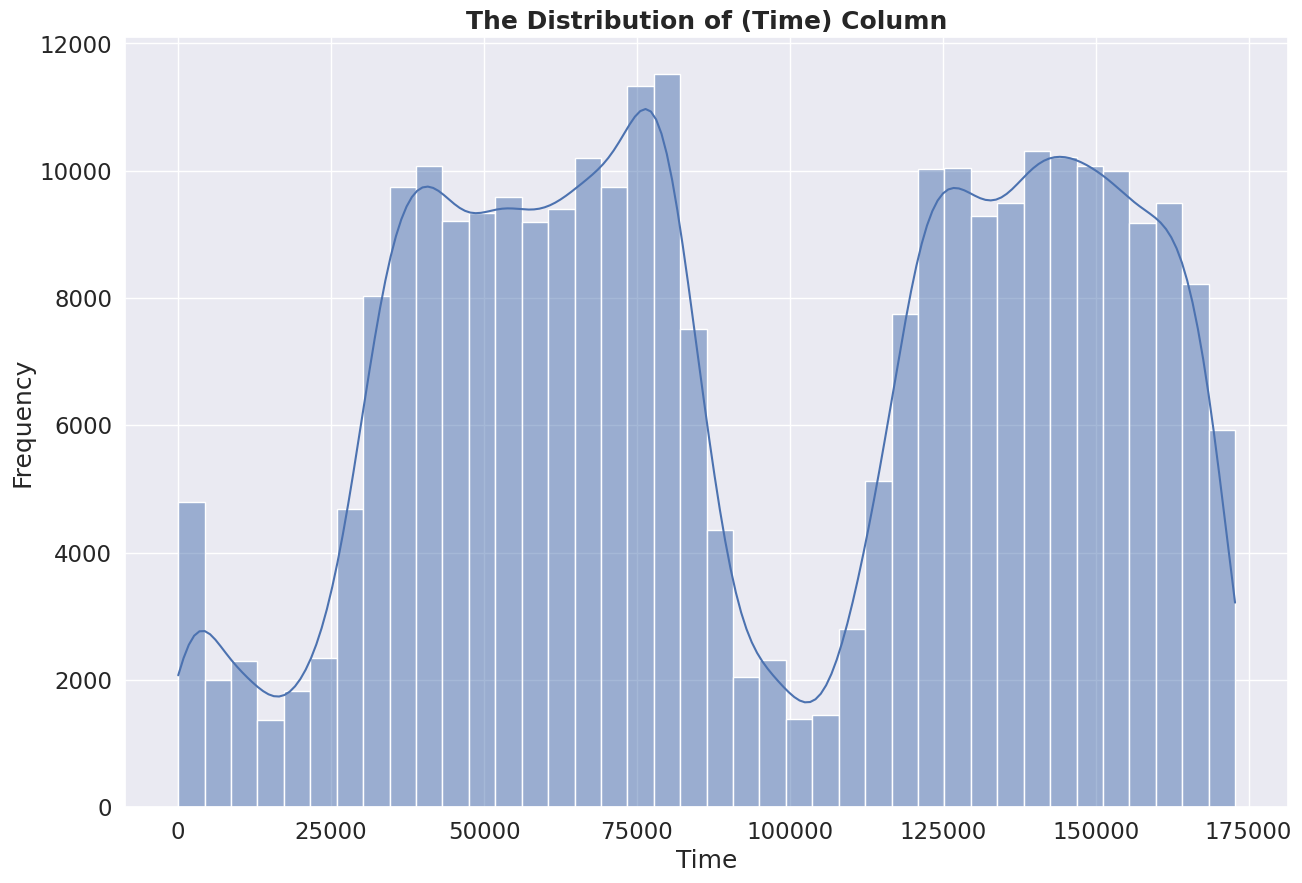

In [14]:
plt.figure(figsize = (15,10))
sns.histplot(data = df, x = "Time", bins = 40, kde = True)
plt.title("The Distribution of (Time) Column", fontweight = 'black')
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

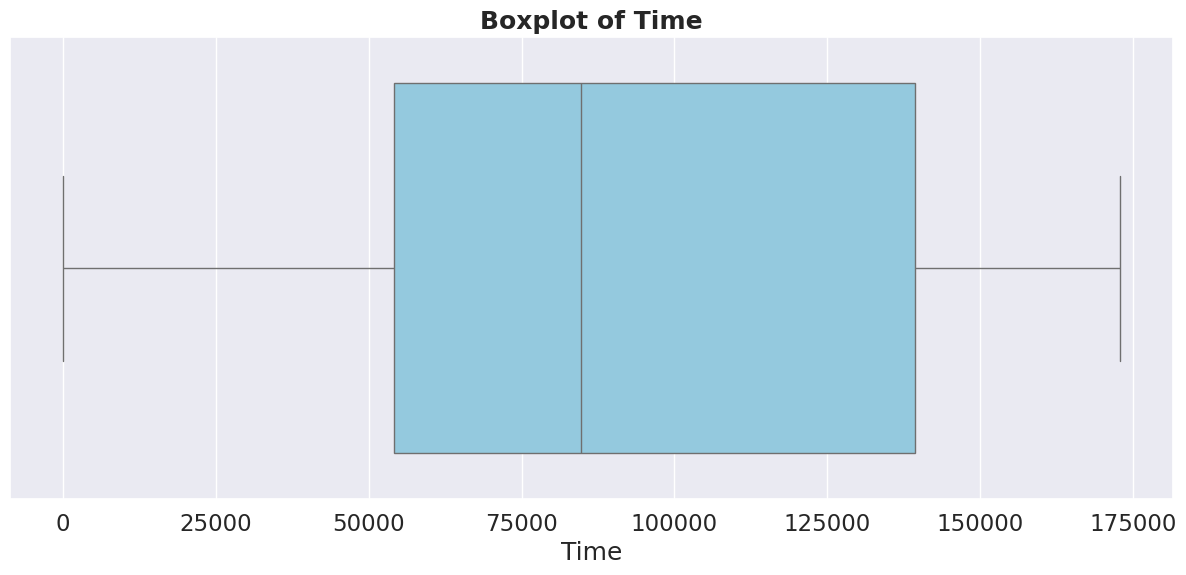

In [15]:
plt.figure(figsize=(15,6))
sns.boxplot(x=df["Time"], color="skyblue")
plt.title("Boxplot of Time", fontweight = 'black')
plt.xlabel("Time")
plt.show()

In [16]:
def analyze_feature(df, column):
    
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    sns.histplot(df[column], bins=40, kde=True, ax=axes[0], color="red")
    axes[0].set_title(f"Distribution of {column}")
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1], color="skyblue")
    axes[1].set_title(f"Boxplot of {column}")
    
    # Violinplot
    sns.violinplot(x=df[column], ax=axes[2], color="lightgreen")
    axes[2].set_title(f"Violin Plot of {column}")
    
    plt.tight_layout()
    plt.show()

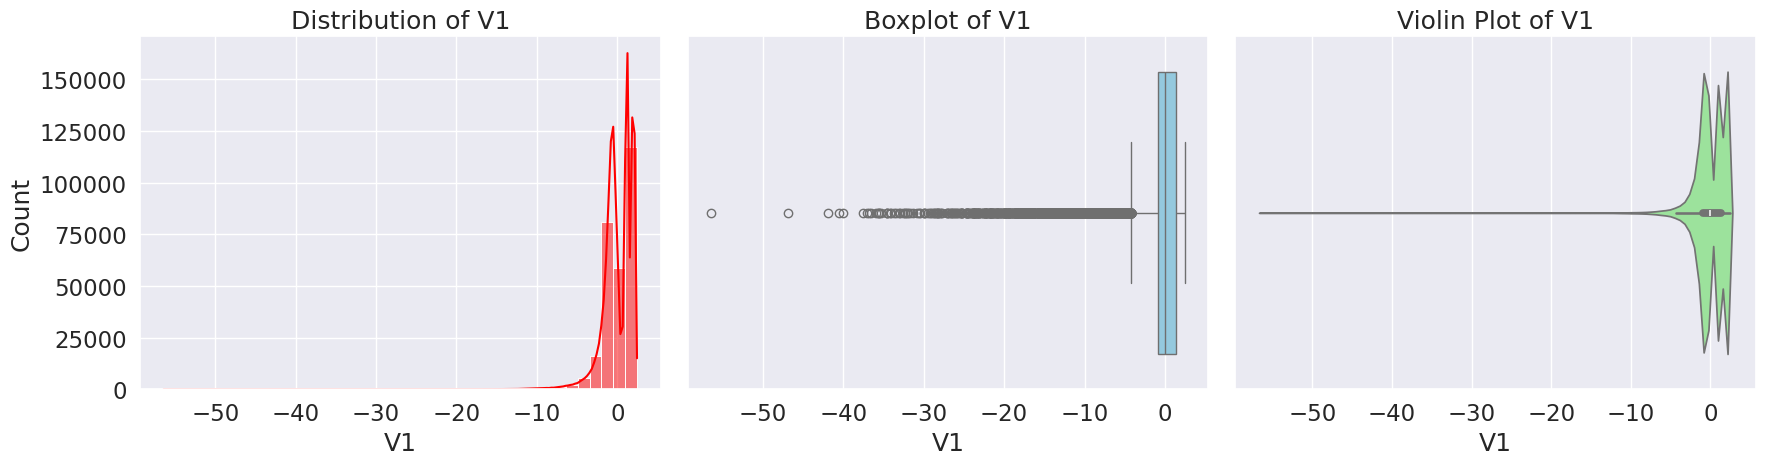

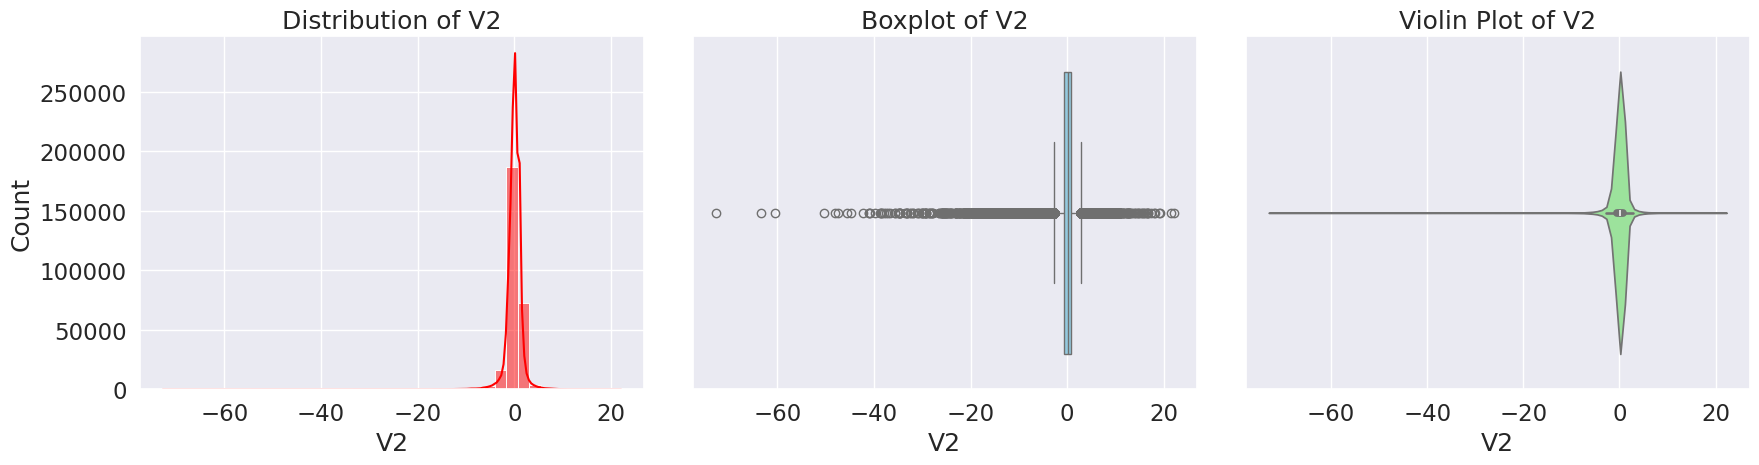

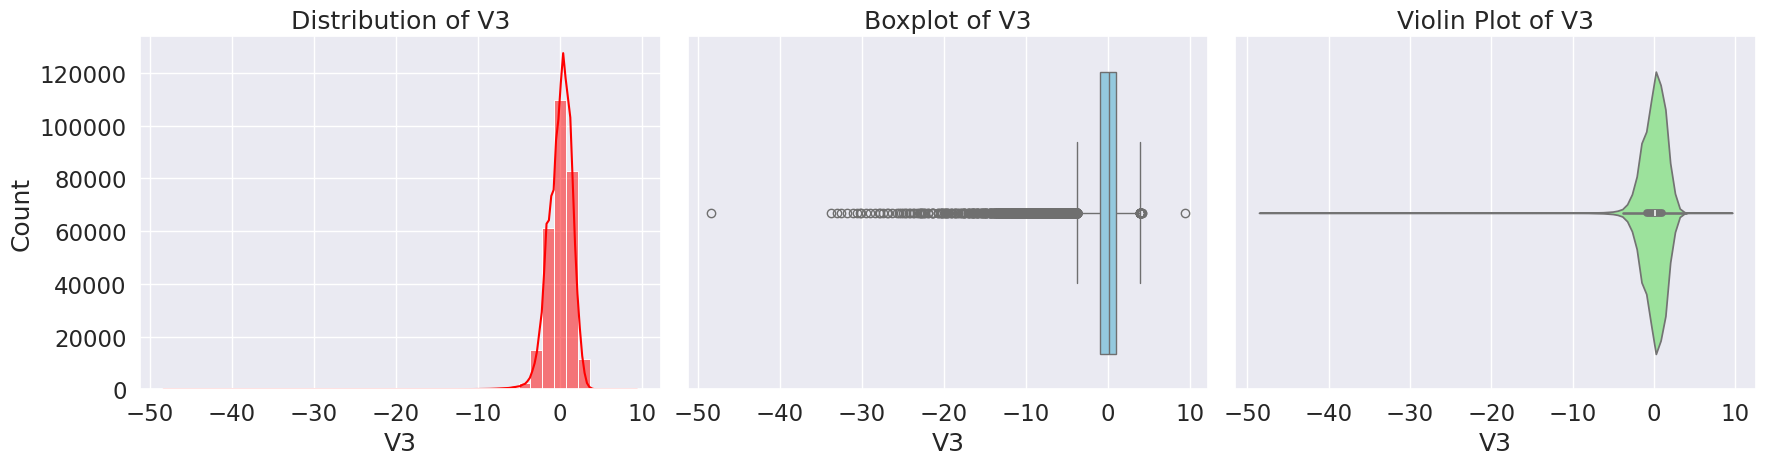

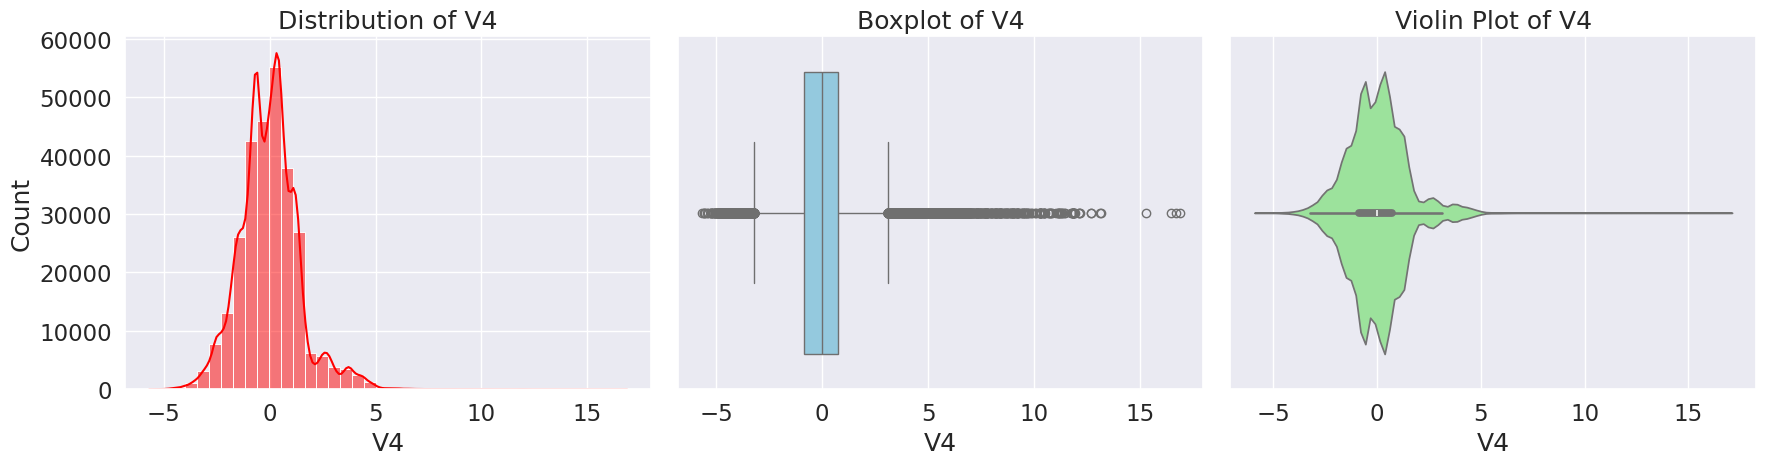

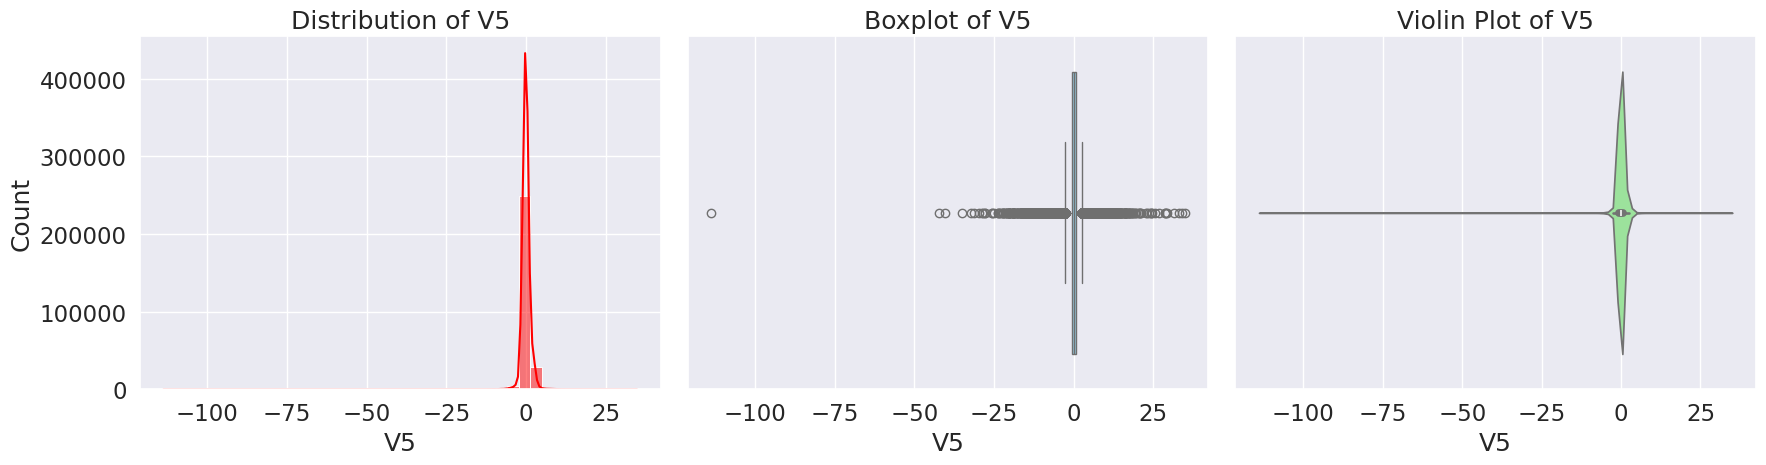

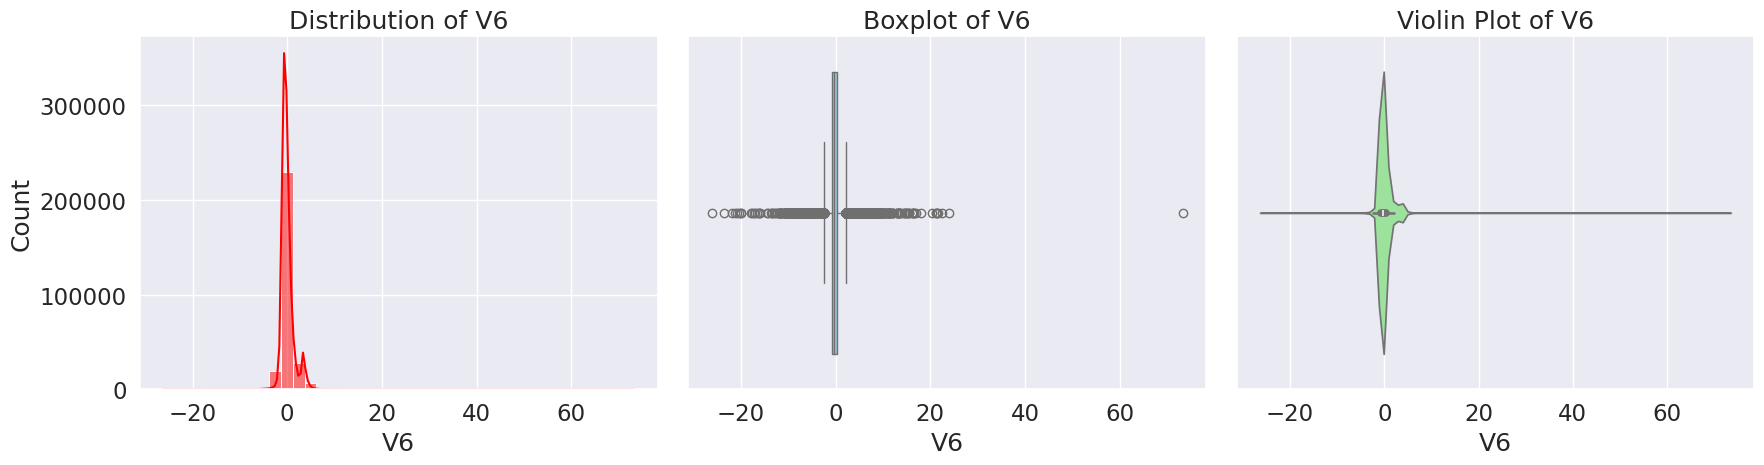

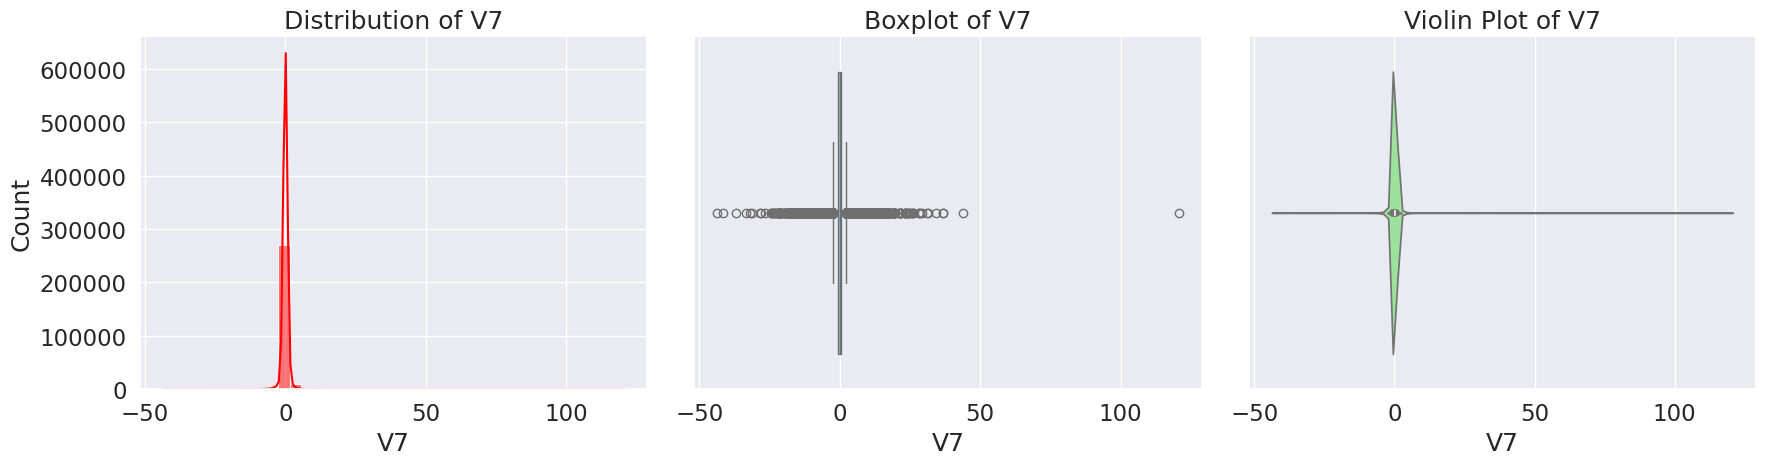

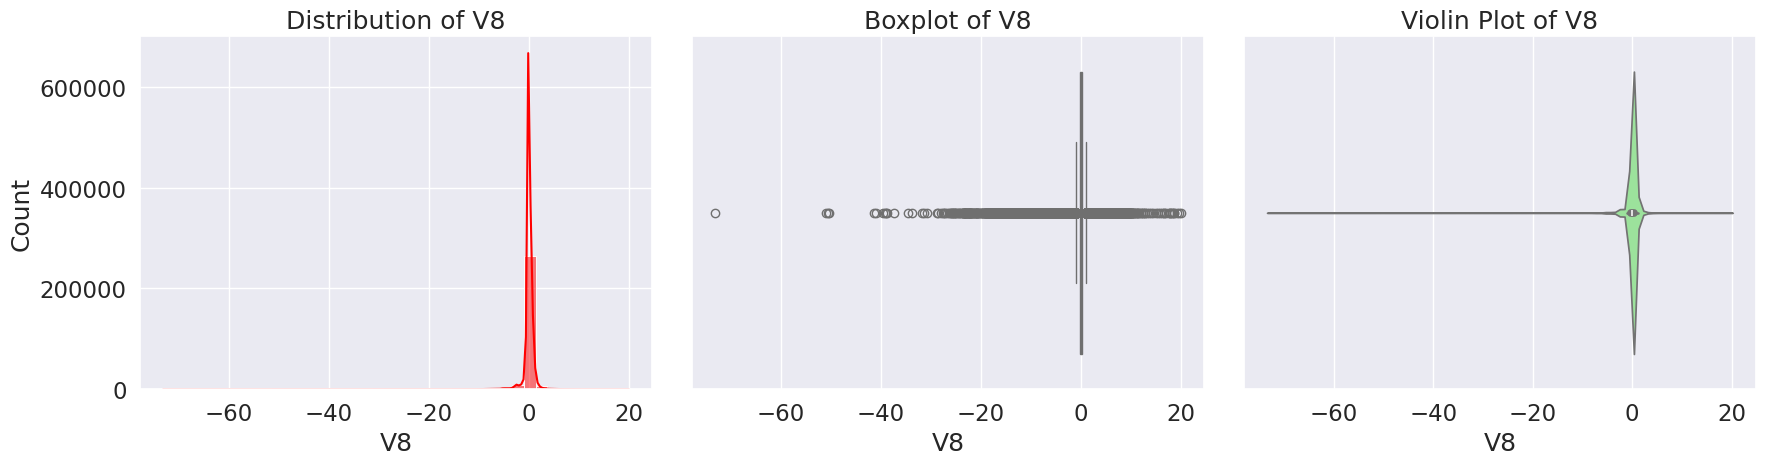

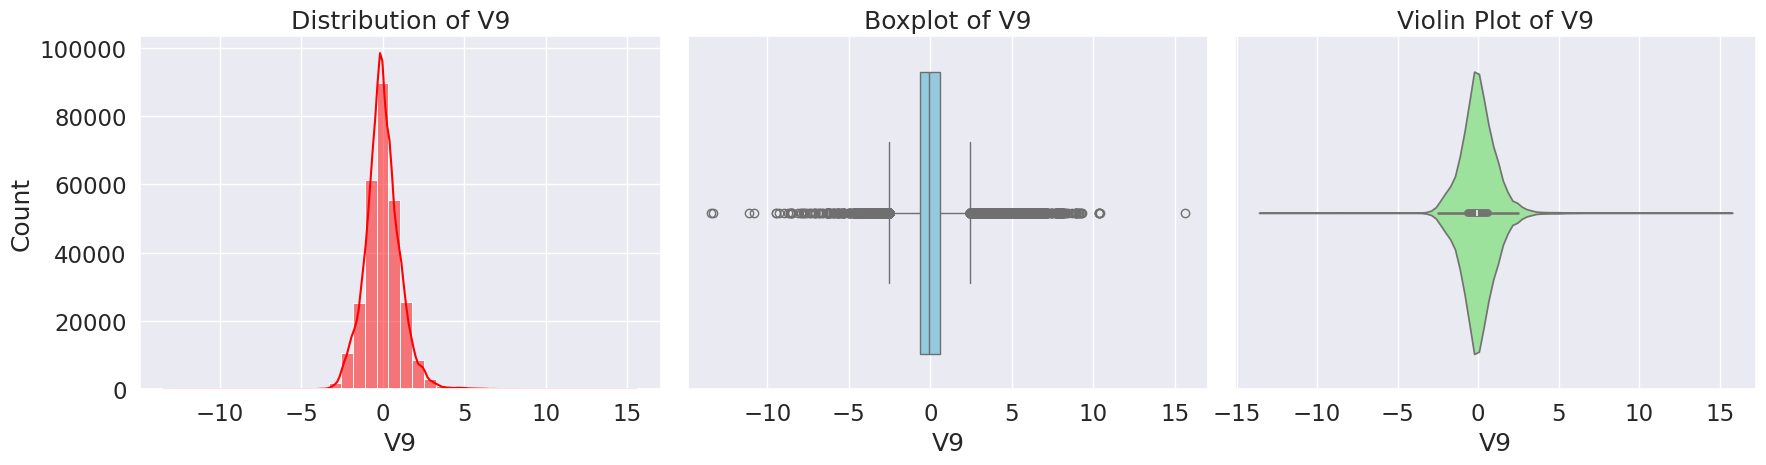

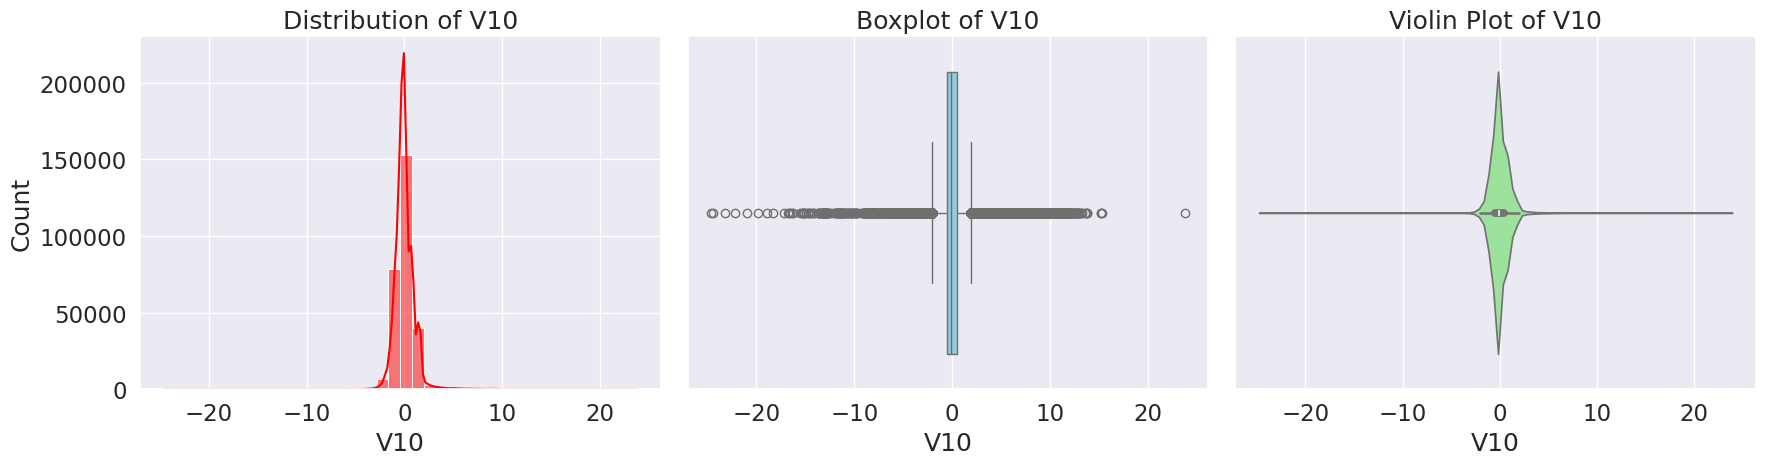

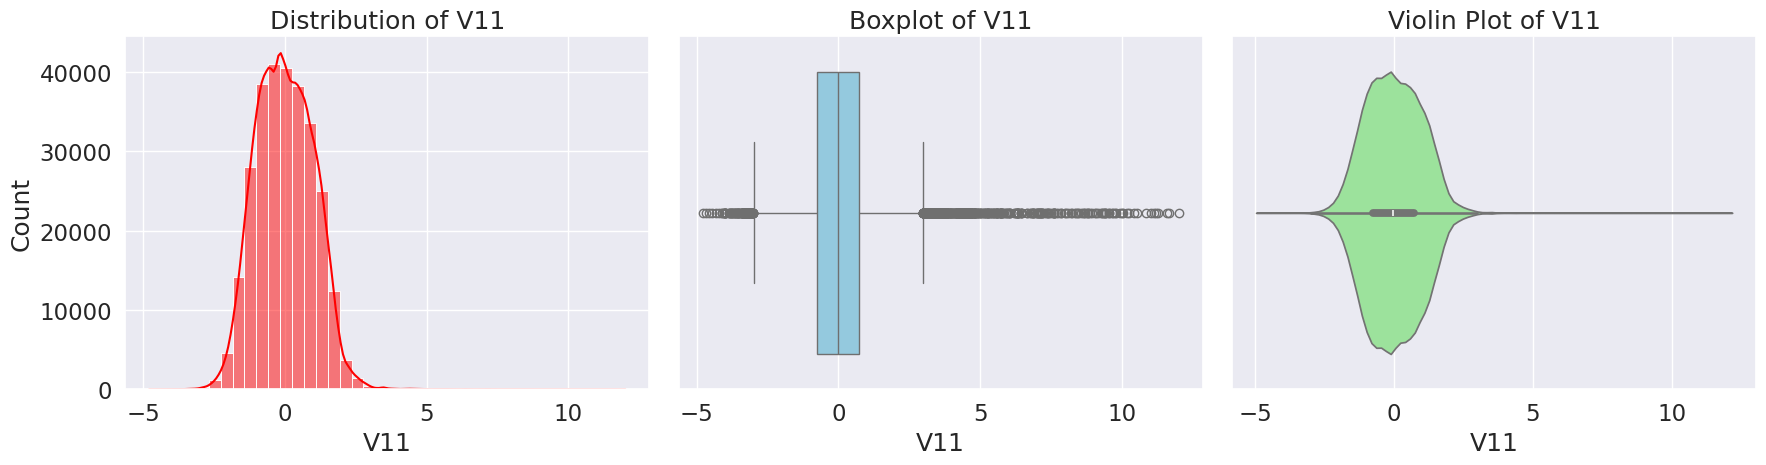

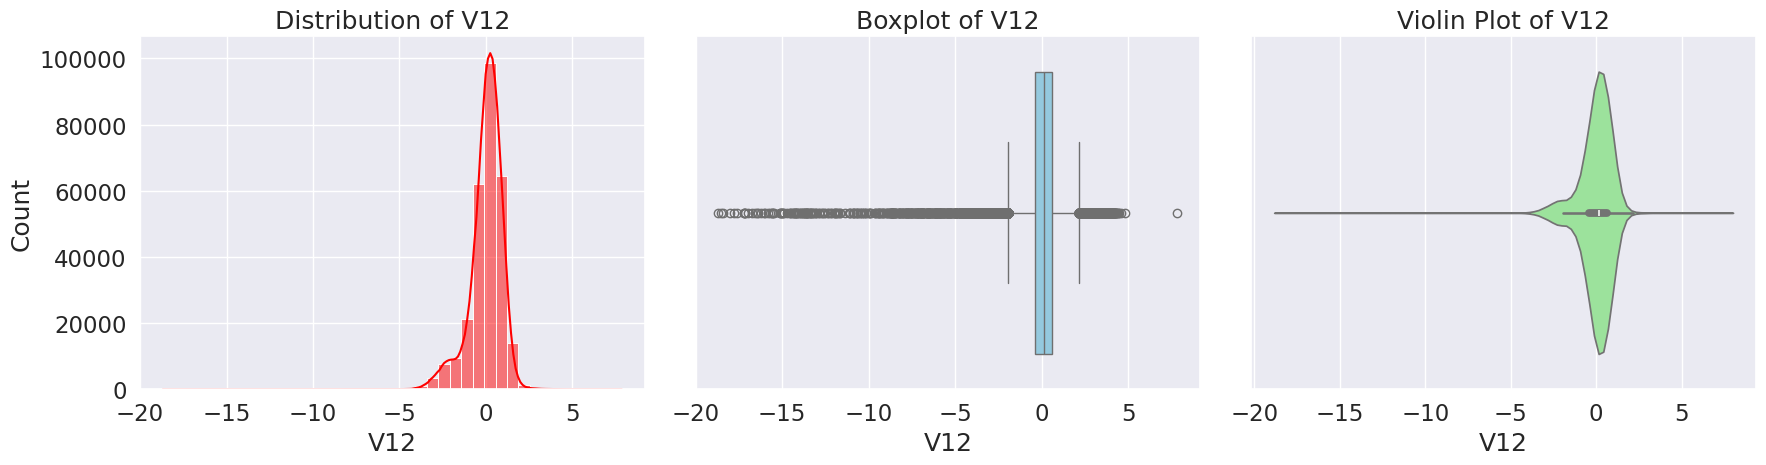

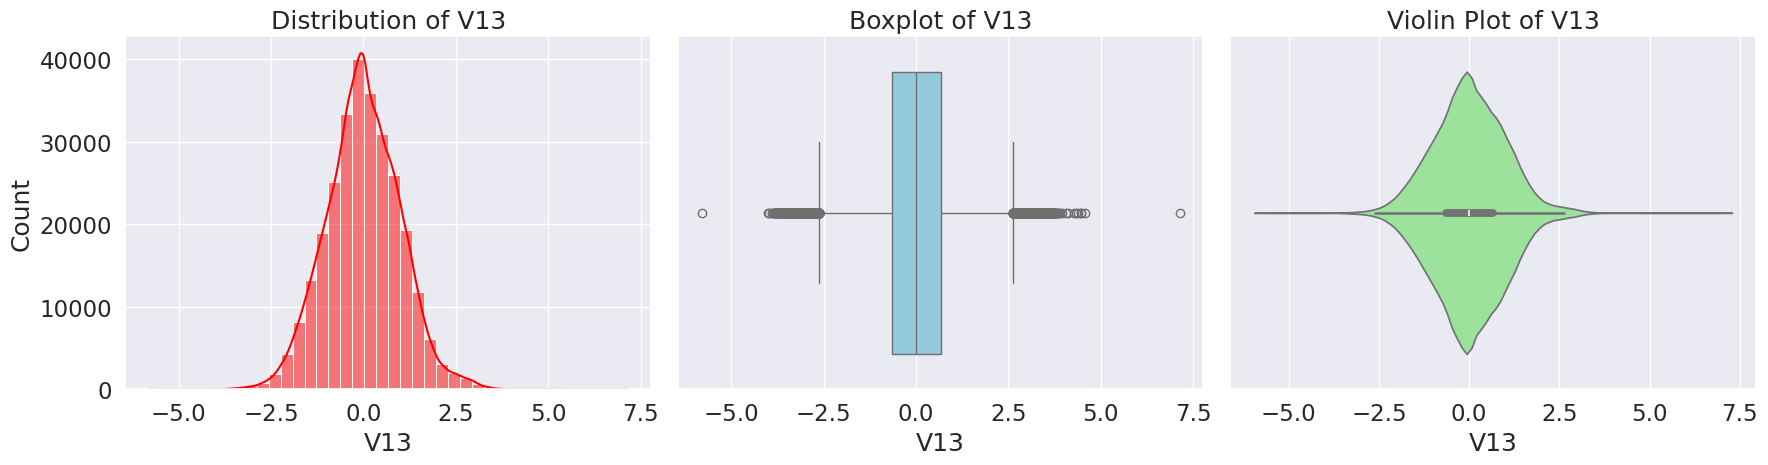

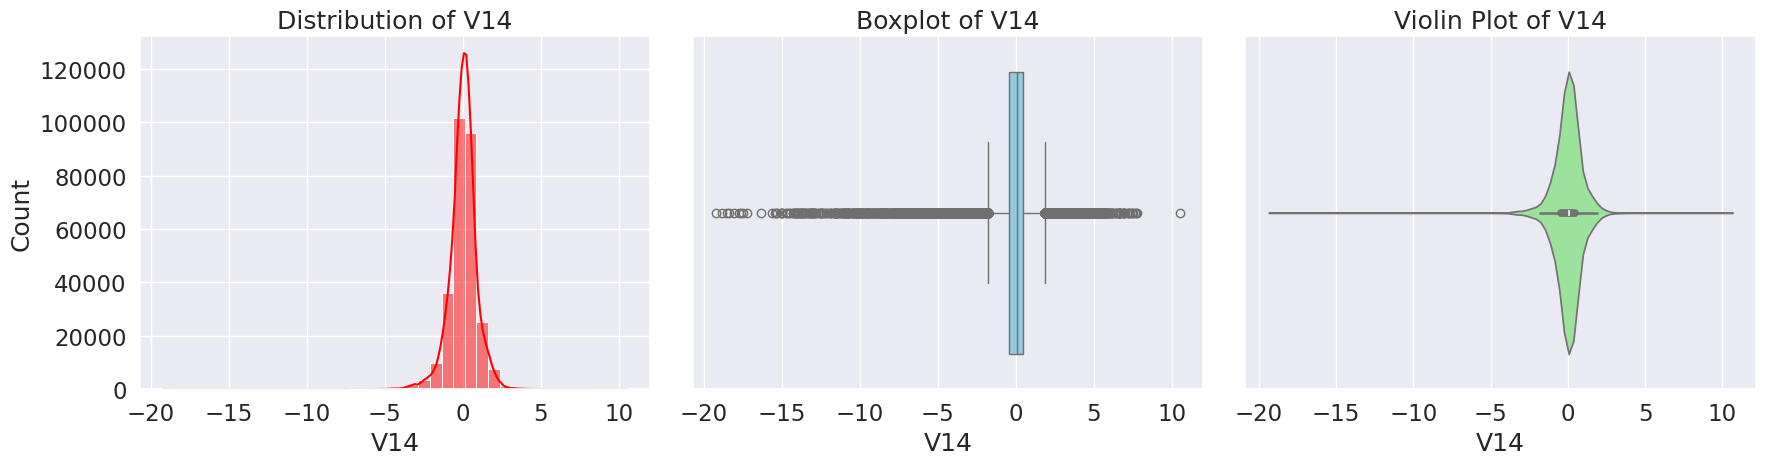

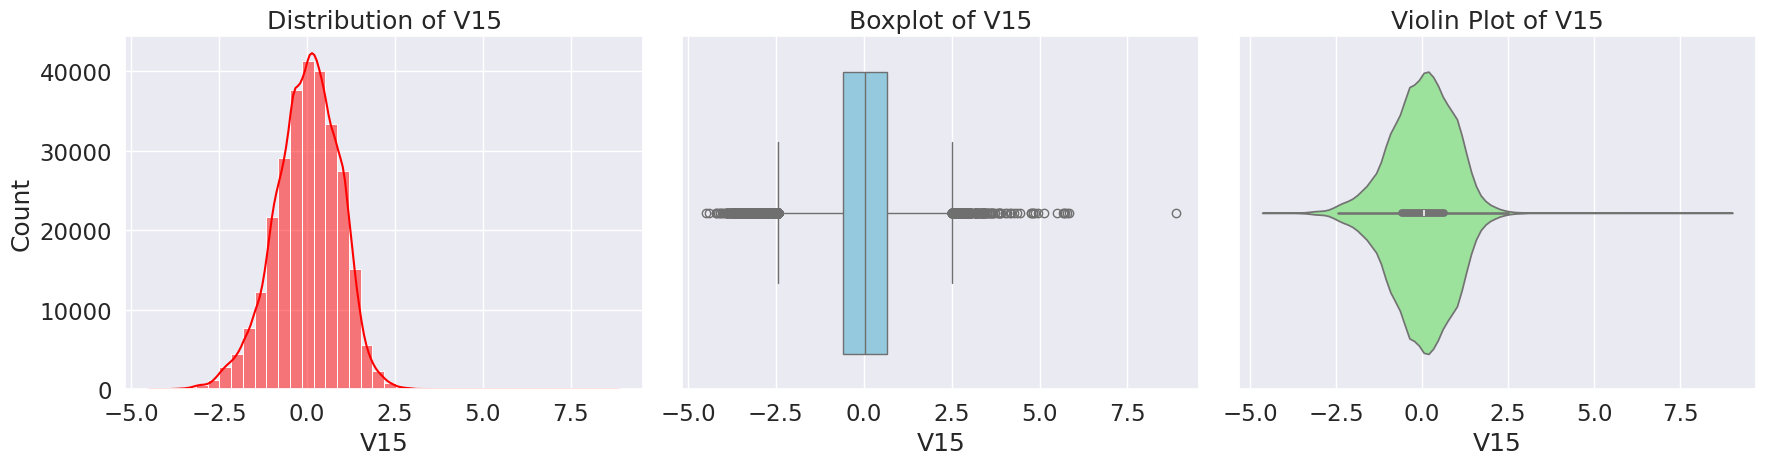

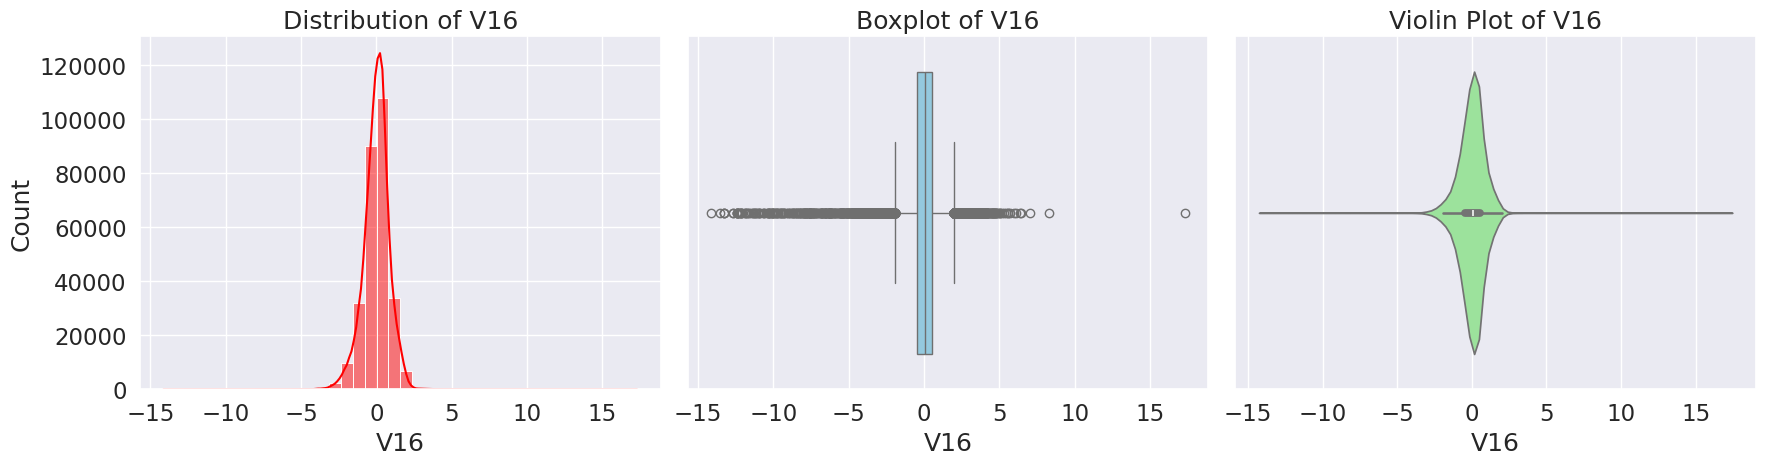

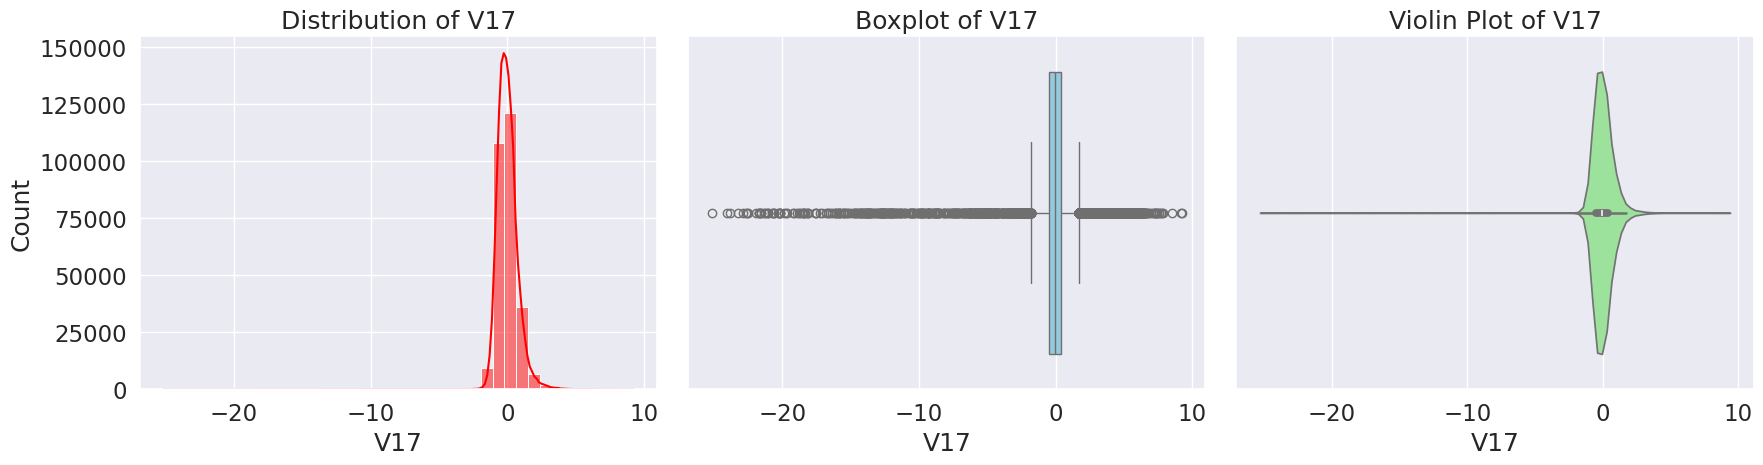

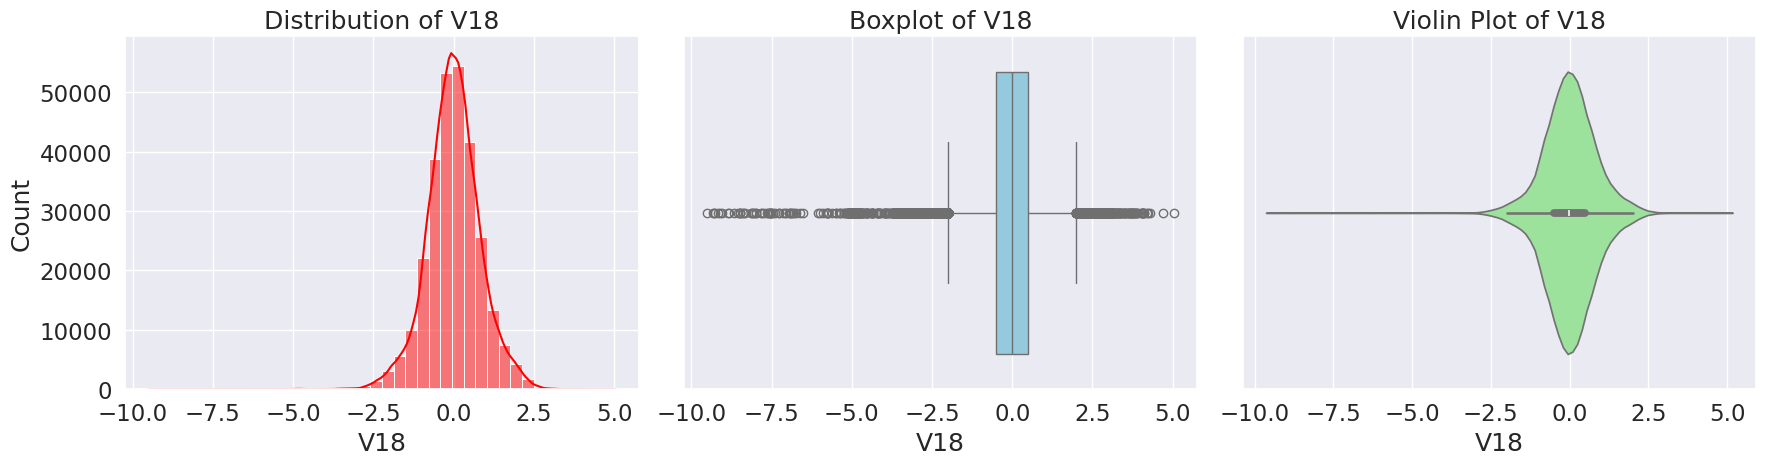

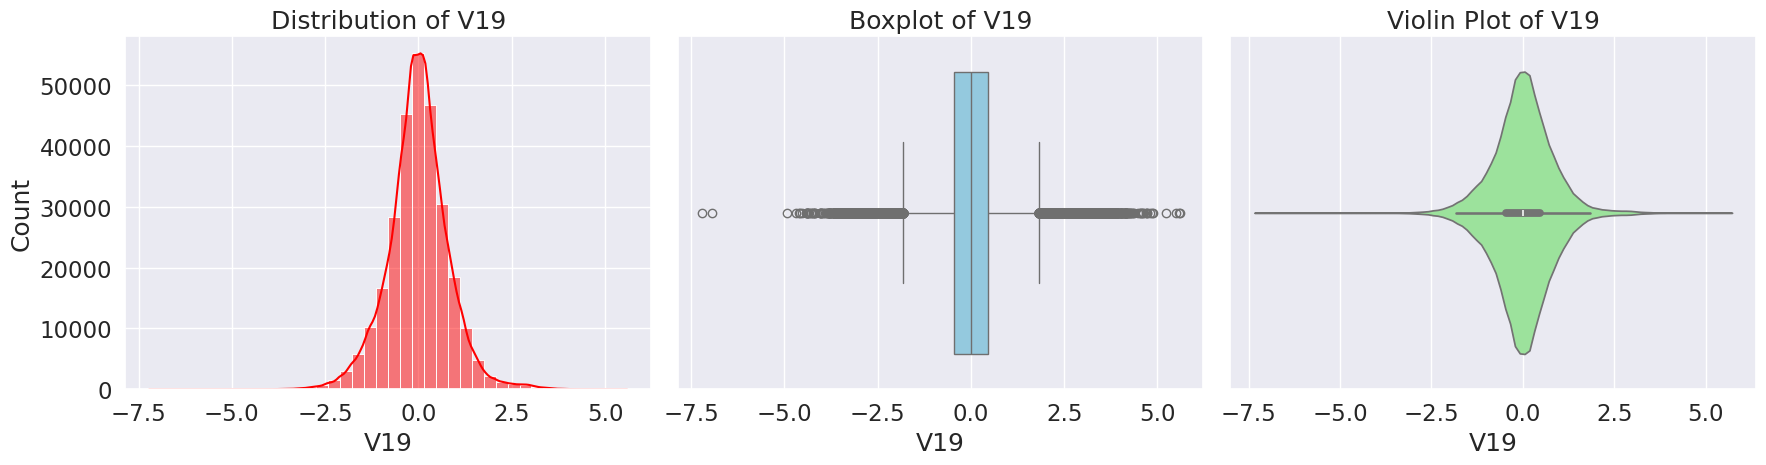

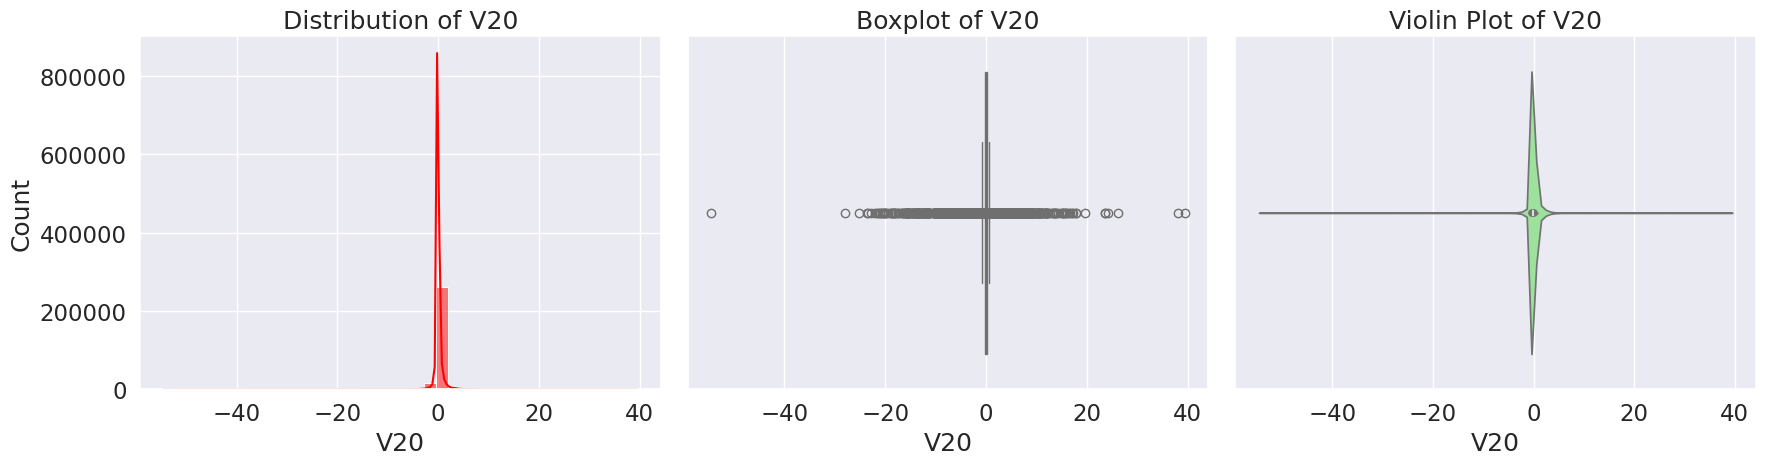

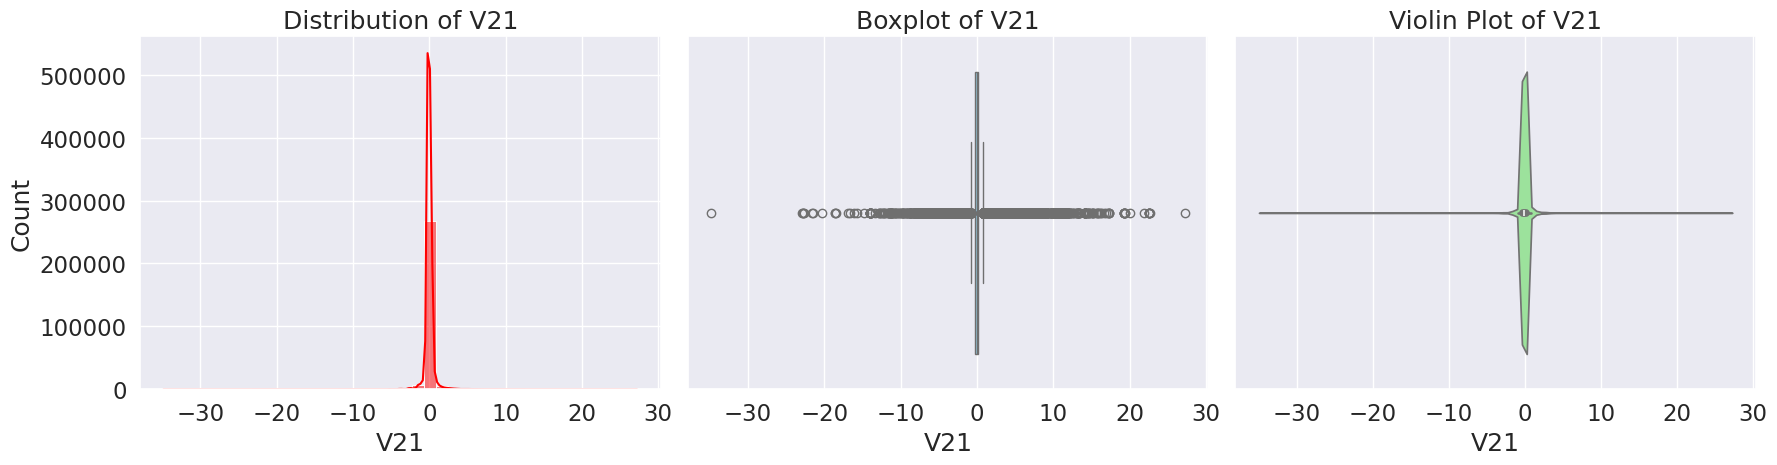

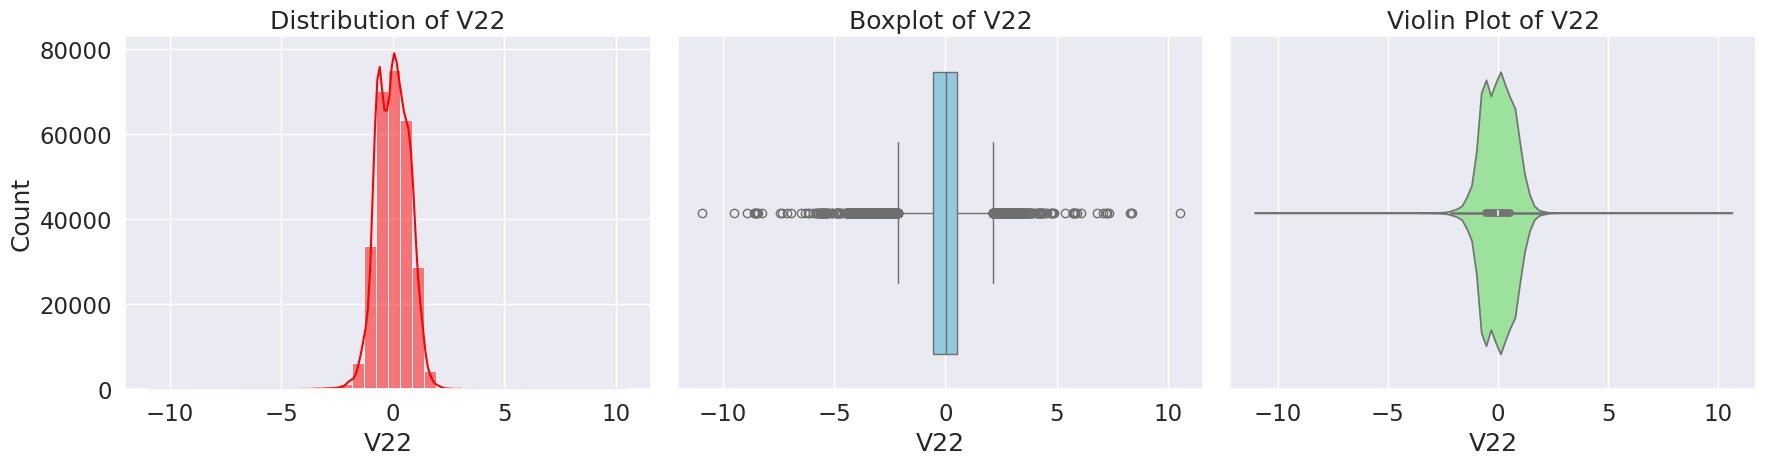

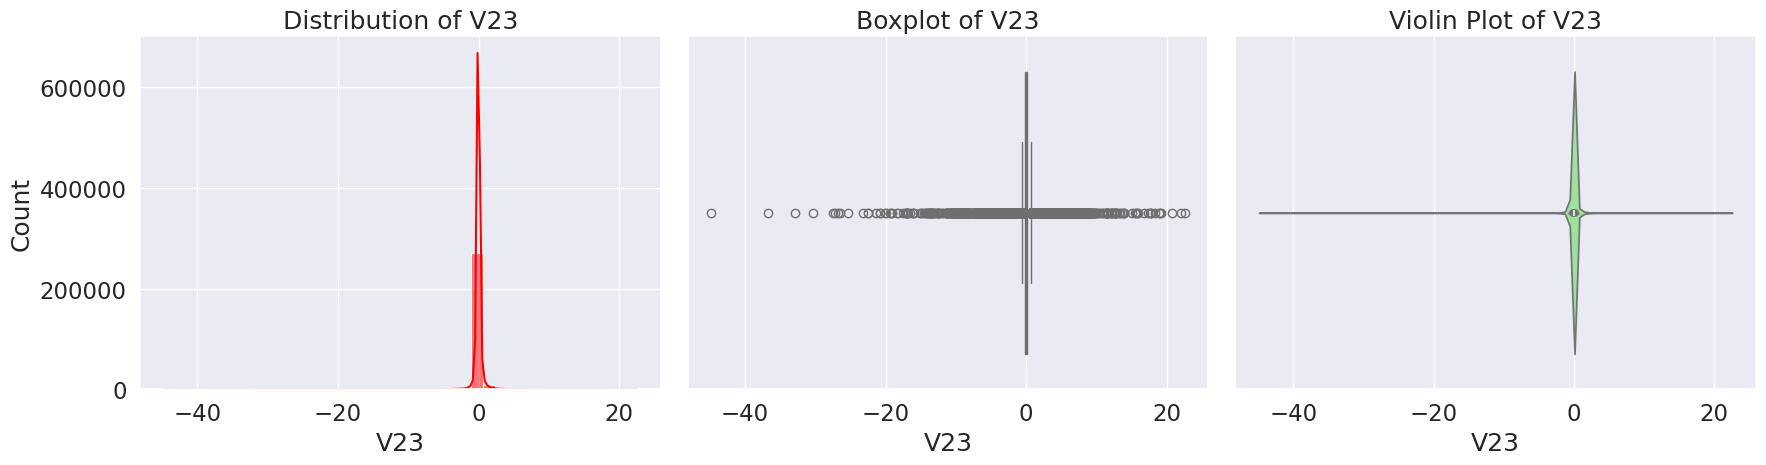

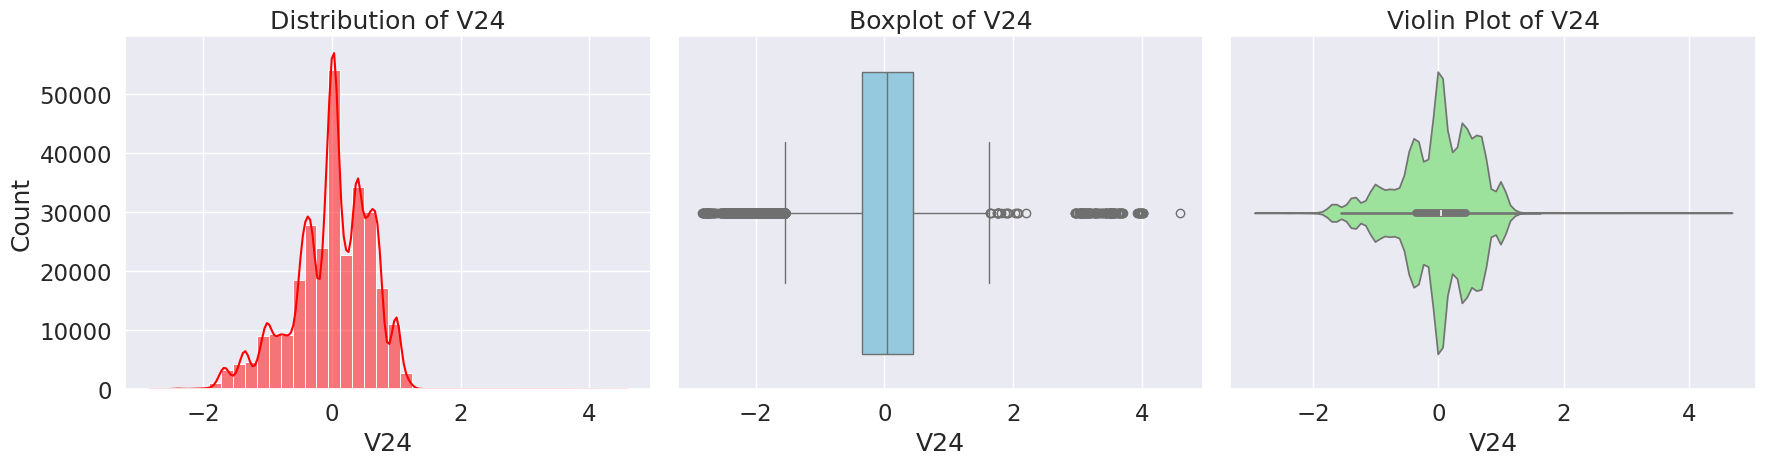

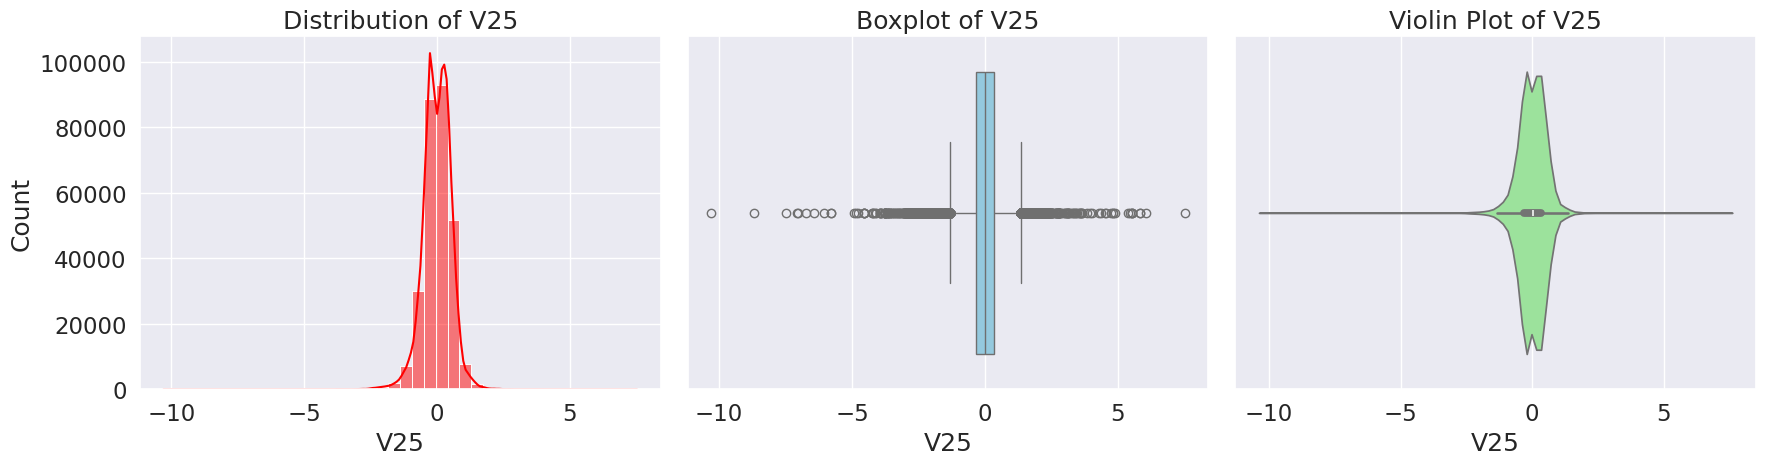

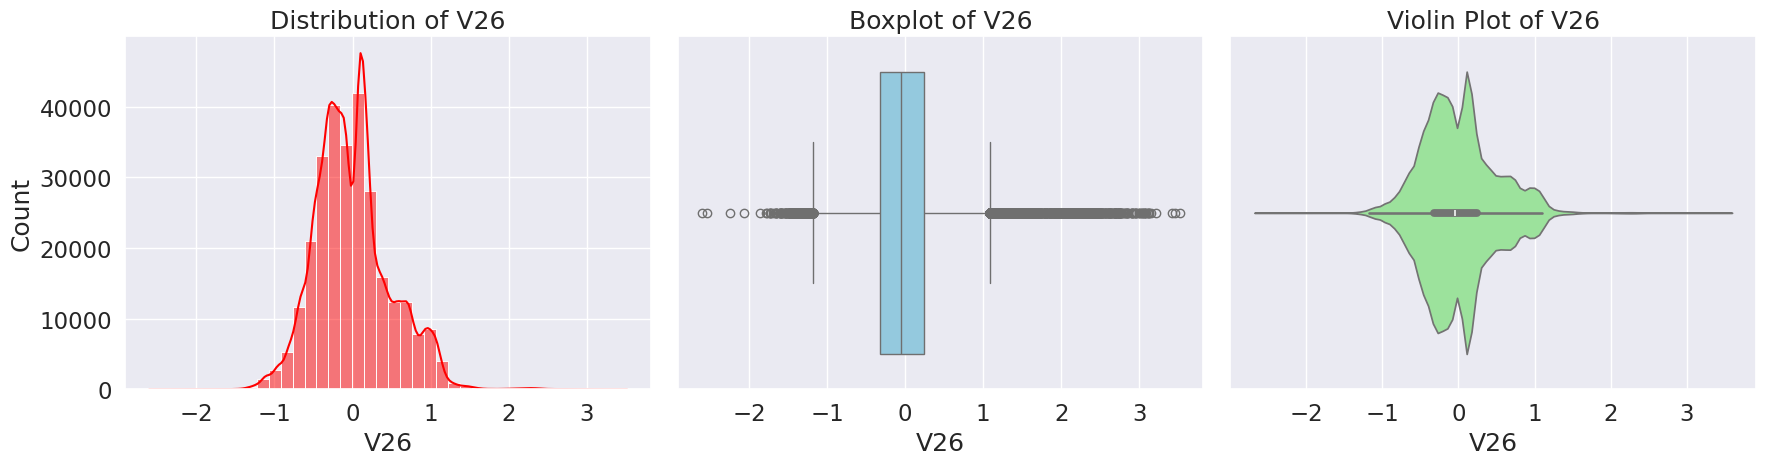

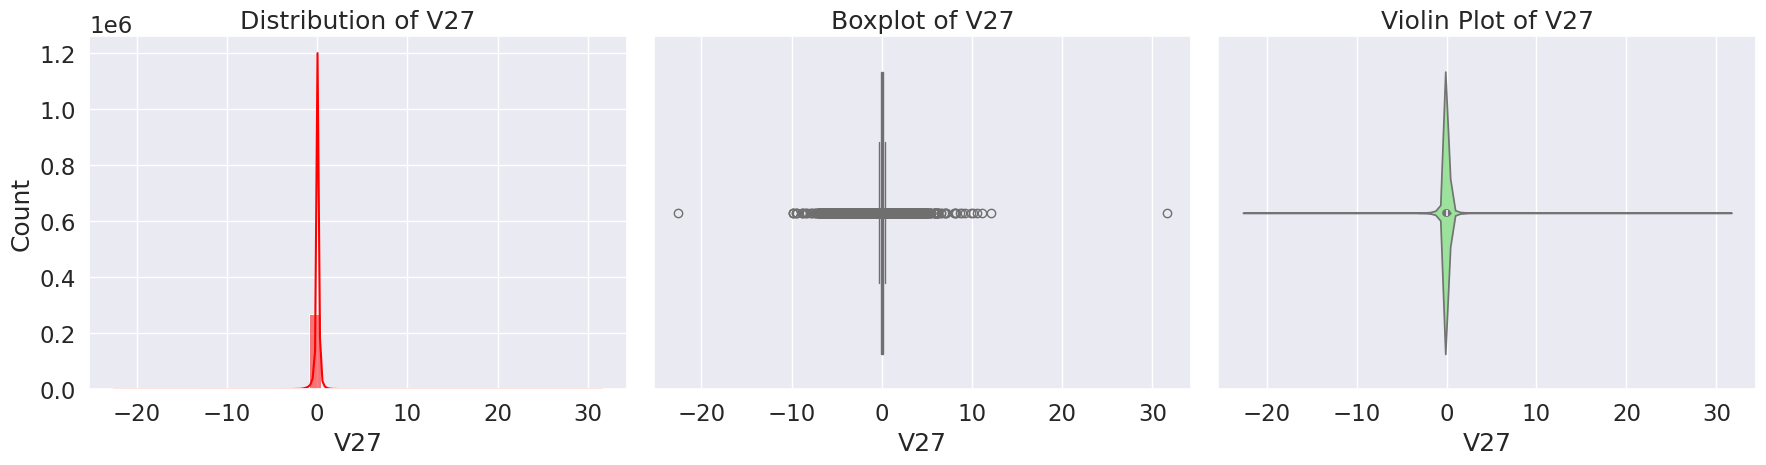

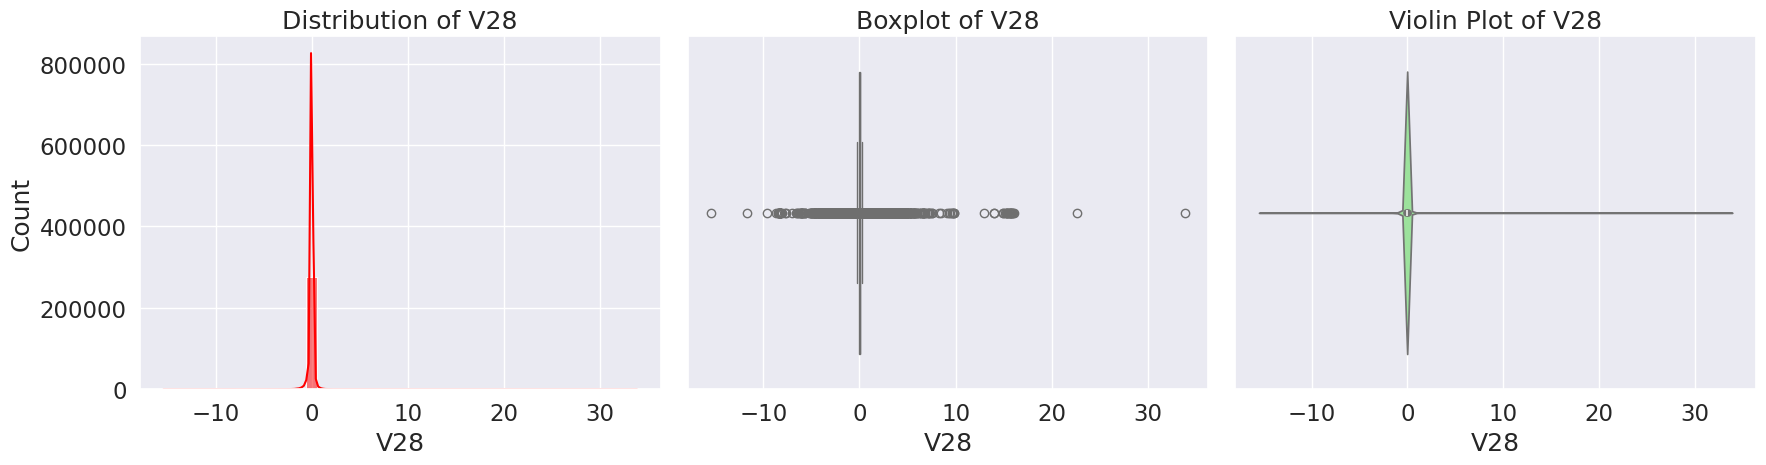

In [17]:
features = [f"V{i}" for i in range(1,29)]

for col in features:
    analyze_feature(df, col)

In [18]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

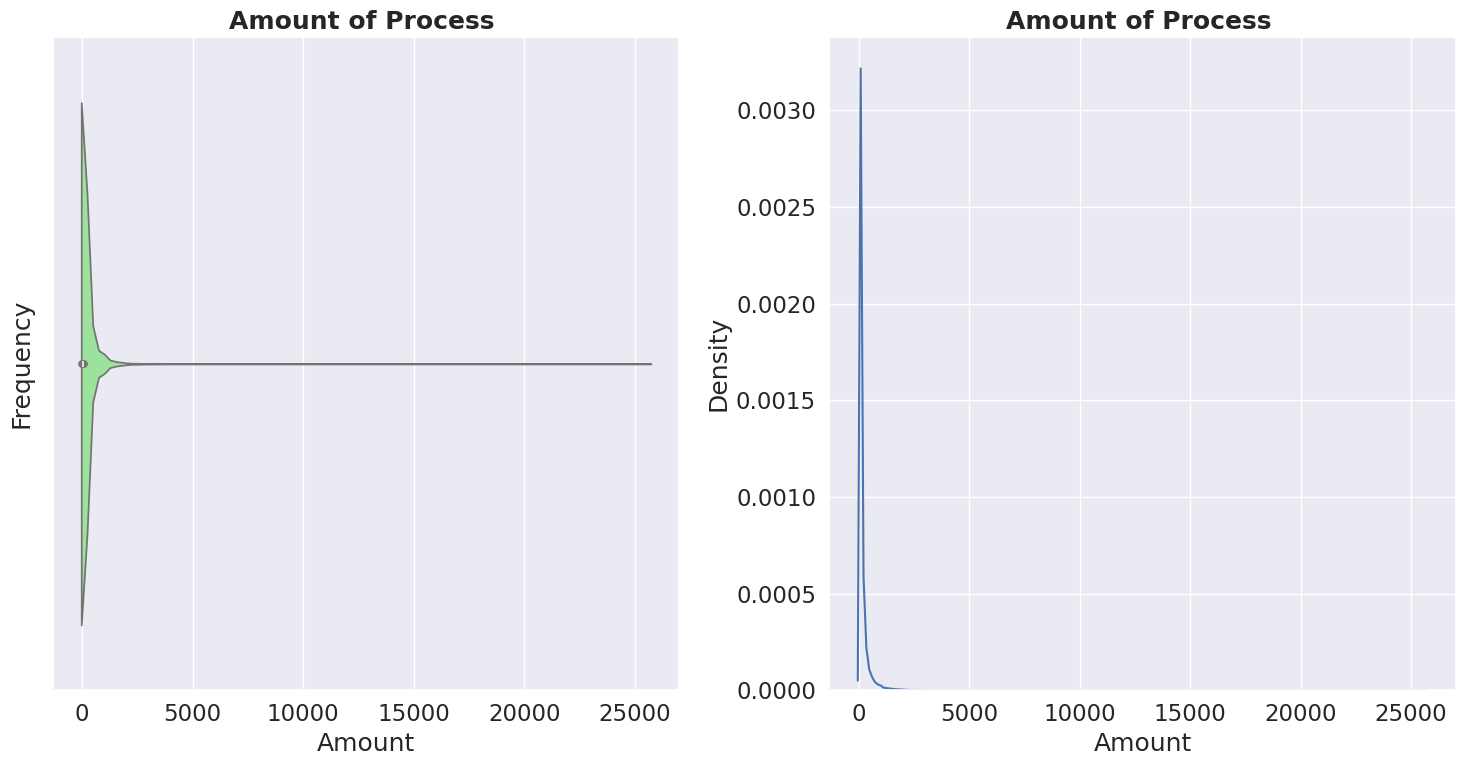

In [19]:
plt.figure(figsize = (15, 8))
plt.subplot(1,2,1)
sns.violinplot(x=df["Amount"], color="lightgreen")
plt.title("Amount of Process ", fontweight = "black")
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.kdeplot(x=df["Amount"])
plt.title("Amount of Process ", fontweight = "black")


plt.tight_layout()
plt.show()

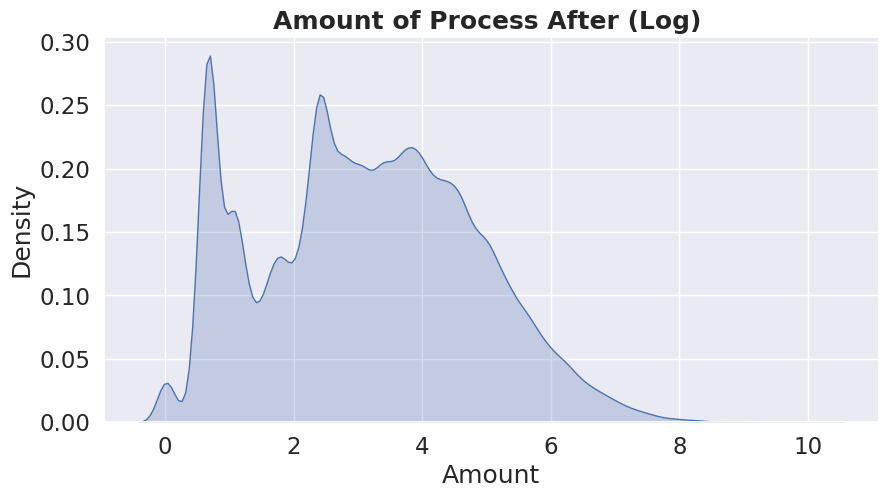

In [20]:
plt.figure(figsize = (10, 5))
sns.kdeplot(x=np.log1p(df["Amount"]), fill = True)
plt.title("Amount of Process After (Log) ", fontweight = "black")

plt.show()

**Class**

In [21]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

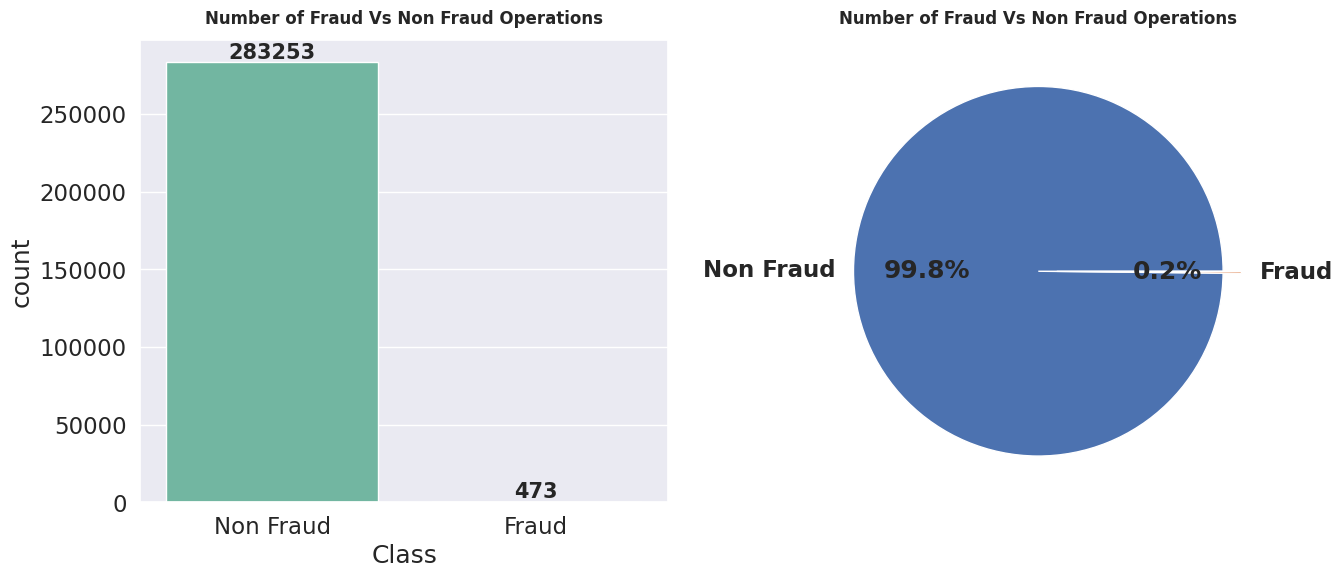

In [22]:
plt.figure(figsize = (15, 6))
plt.subplot(1,2, 1)
ax = sns.countplot(data = df, x = 'Class', palette = 'Set2')
for container in ax.containers:
    ax.bar_label(container, fontweight="black", size = 15)
plt.title("Number of Fraud Vs Non Fraud Operations",fontweight="black",size=12,pad=12)
plt.xticks(ticks=ax.get_xticks(), labels=['Non Fraud', 'Fraud'])



plt.subplot(1,2,2)
plt.pie(df['Class'].value_counts(), autopct = '%1.1f%%', labels=['Non Fraud', 'Fraud'] , explode = [0,0.1], textprops={"fontweight":"black"})
plt.title("Number of Fraud Vs Non Fraud Operations",fontweight="black",size=12,pad=12)

plt.show()

### Bivariate Analysis

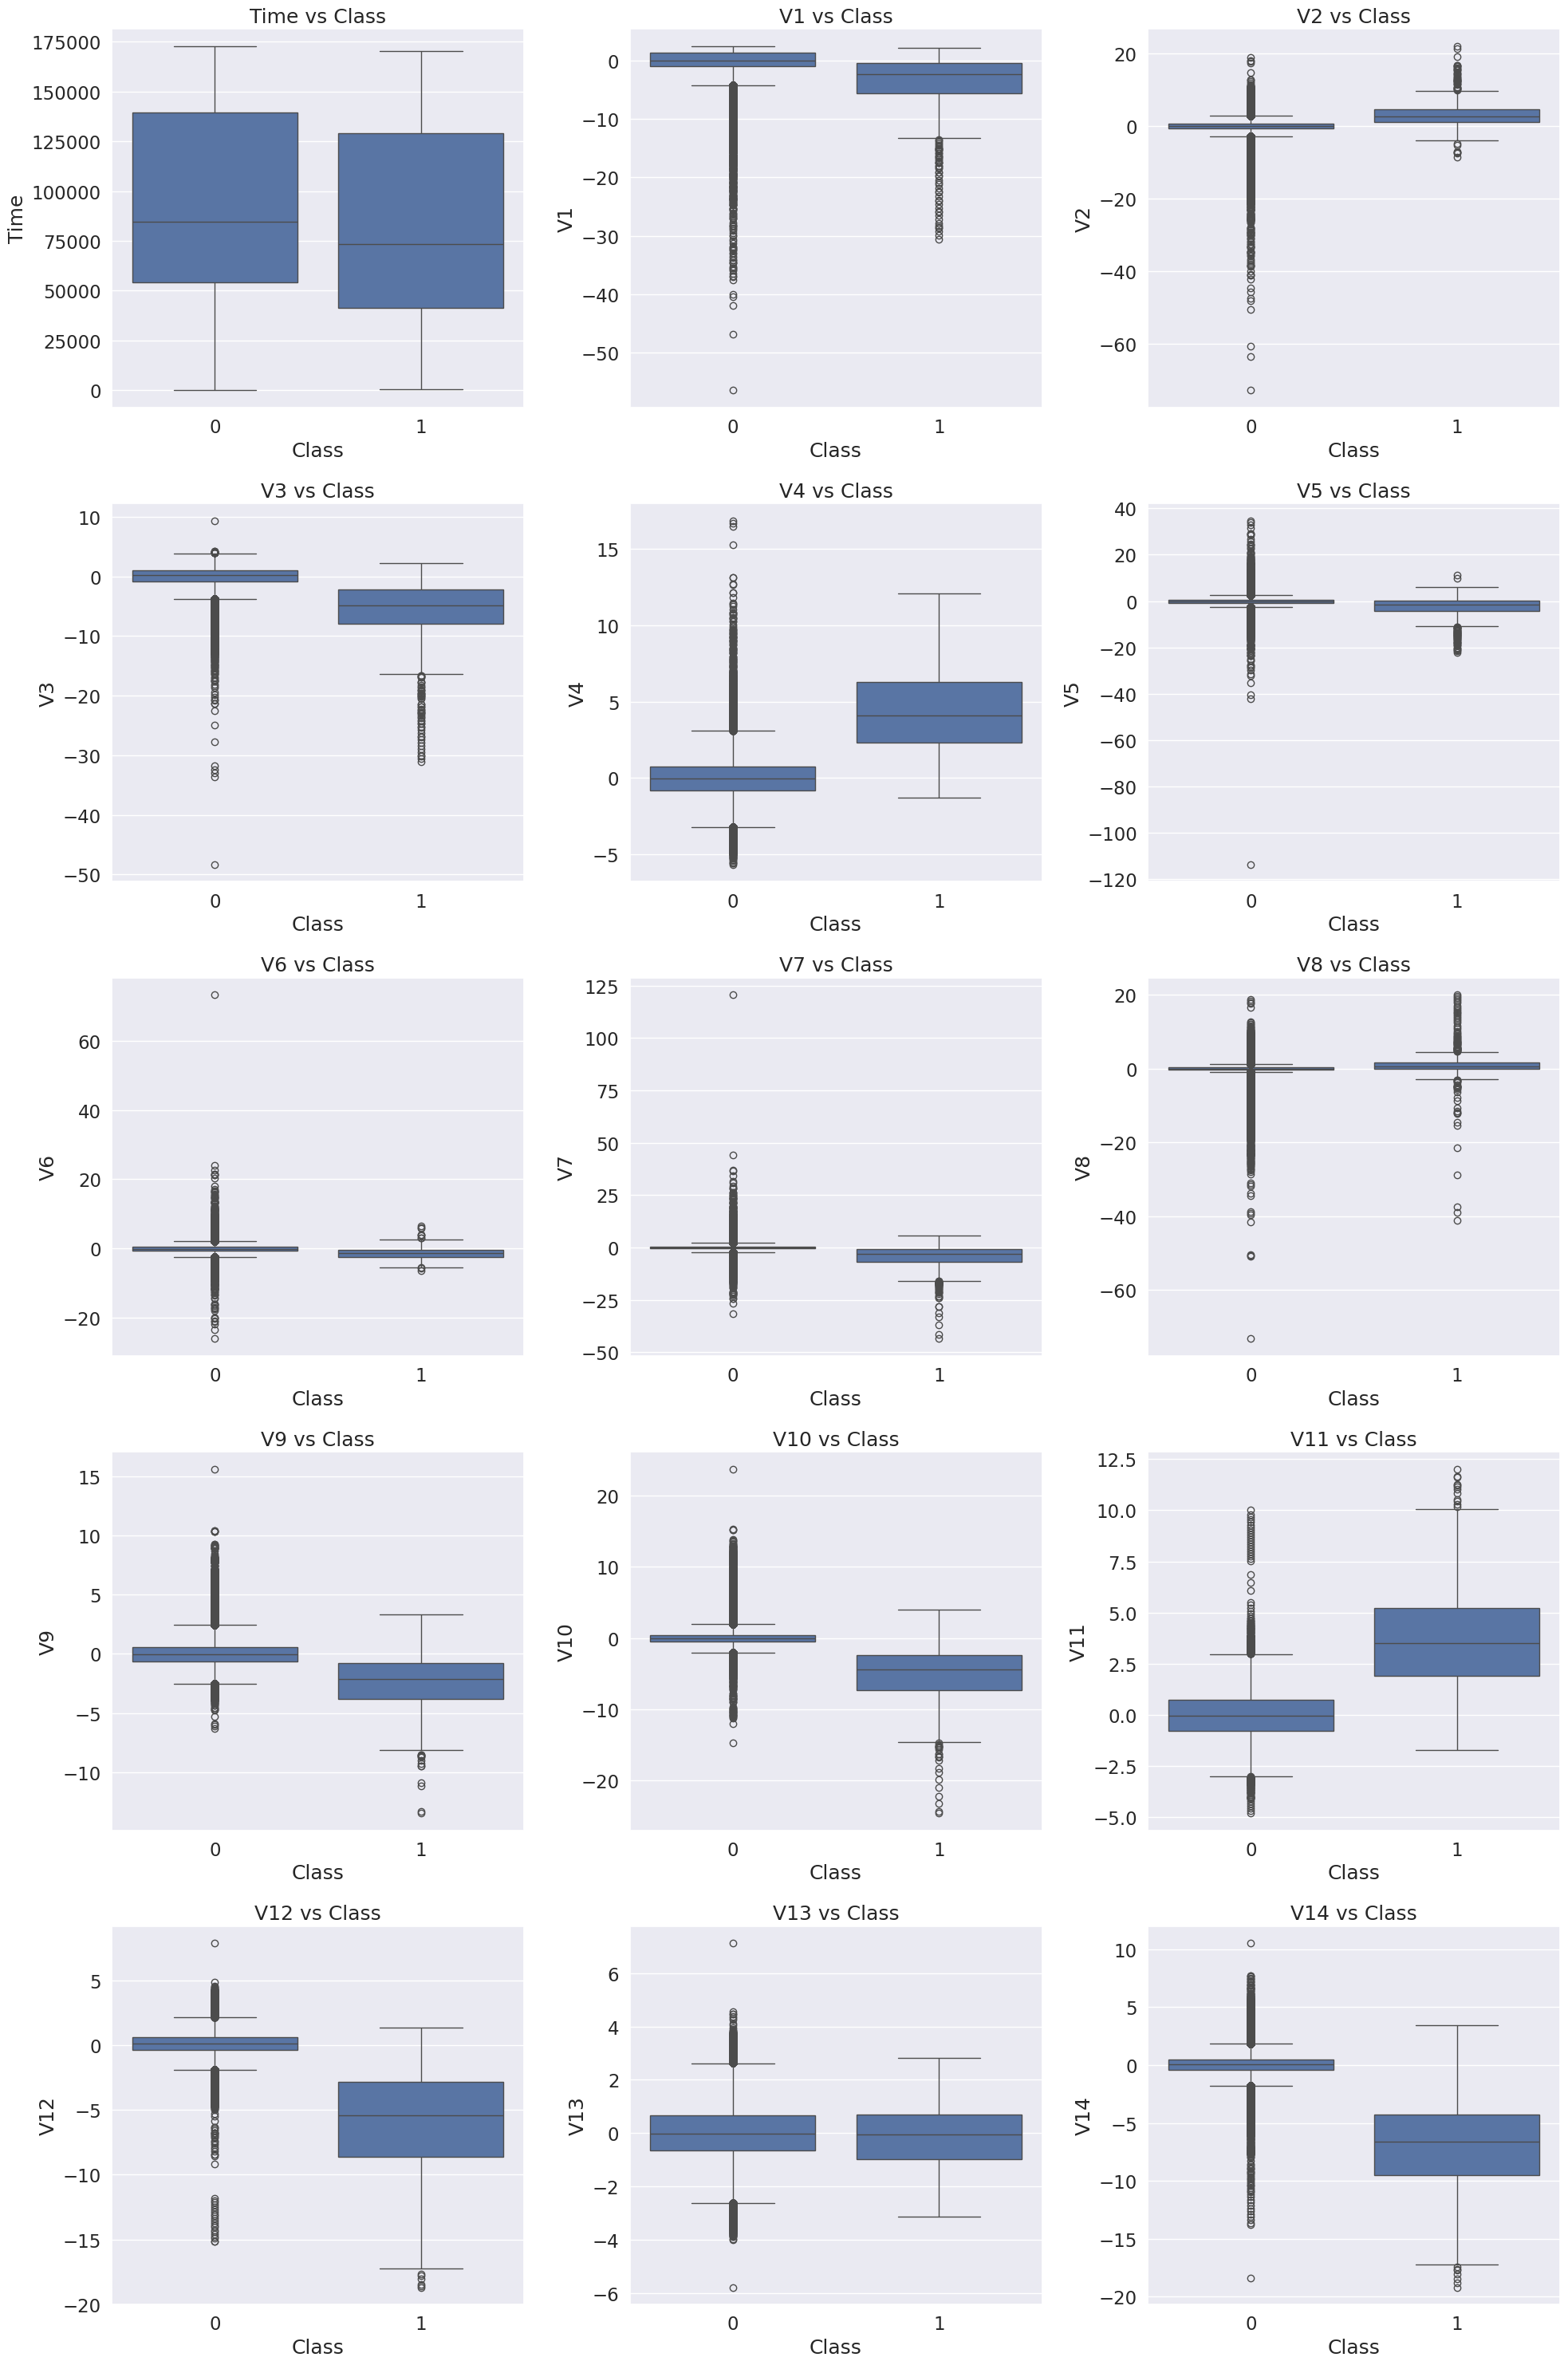

In [23]:
numeric_columns = df.drop(columns=["Class"]).columns  

first_half = numeric_columns[:15]   # Time → V14
second_half = numeric_columns[15:]  # V15 → Amount

plt.figure(figsize=(20, 30))
for i, feature in enumerate(first_half, start=1):
    plt.subplot(5, 3, i)  
    sns.boxplot(x="Class", y=feature, data=df)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Class")
plt.tight_layout()
plt.show()

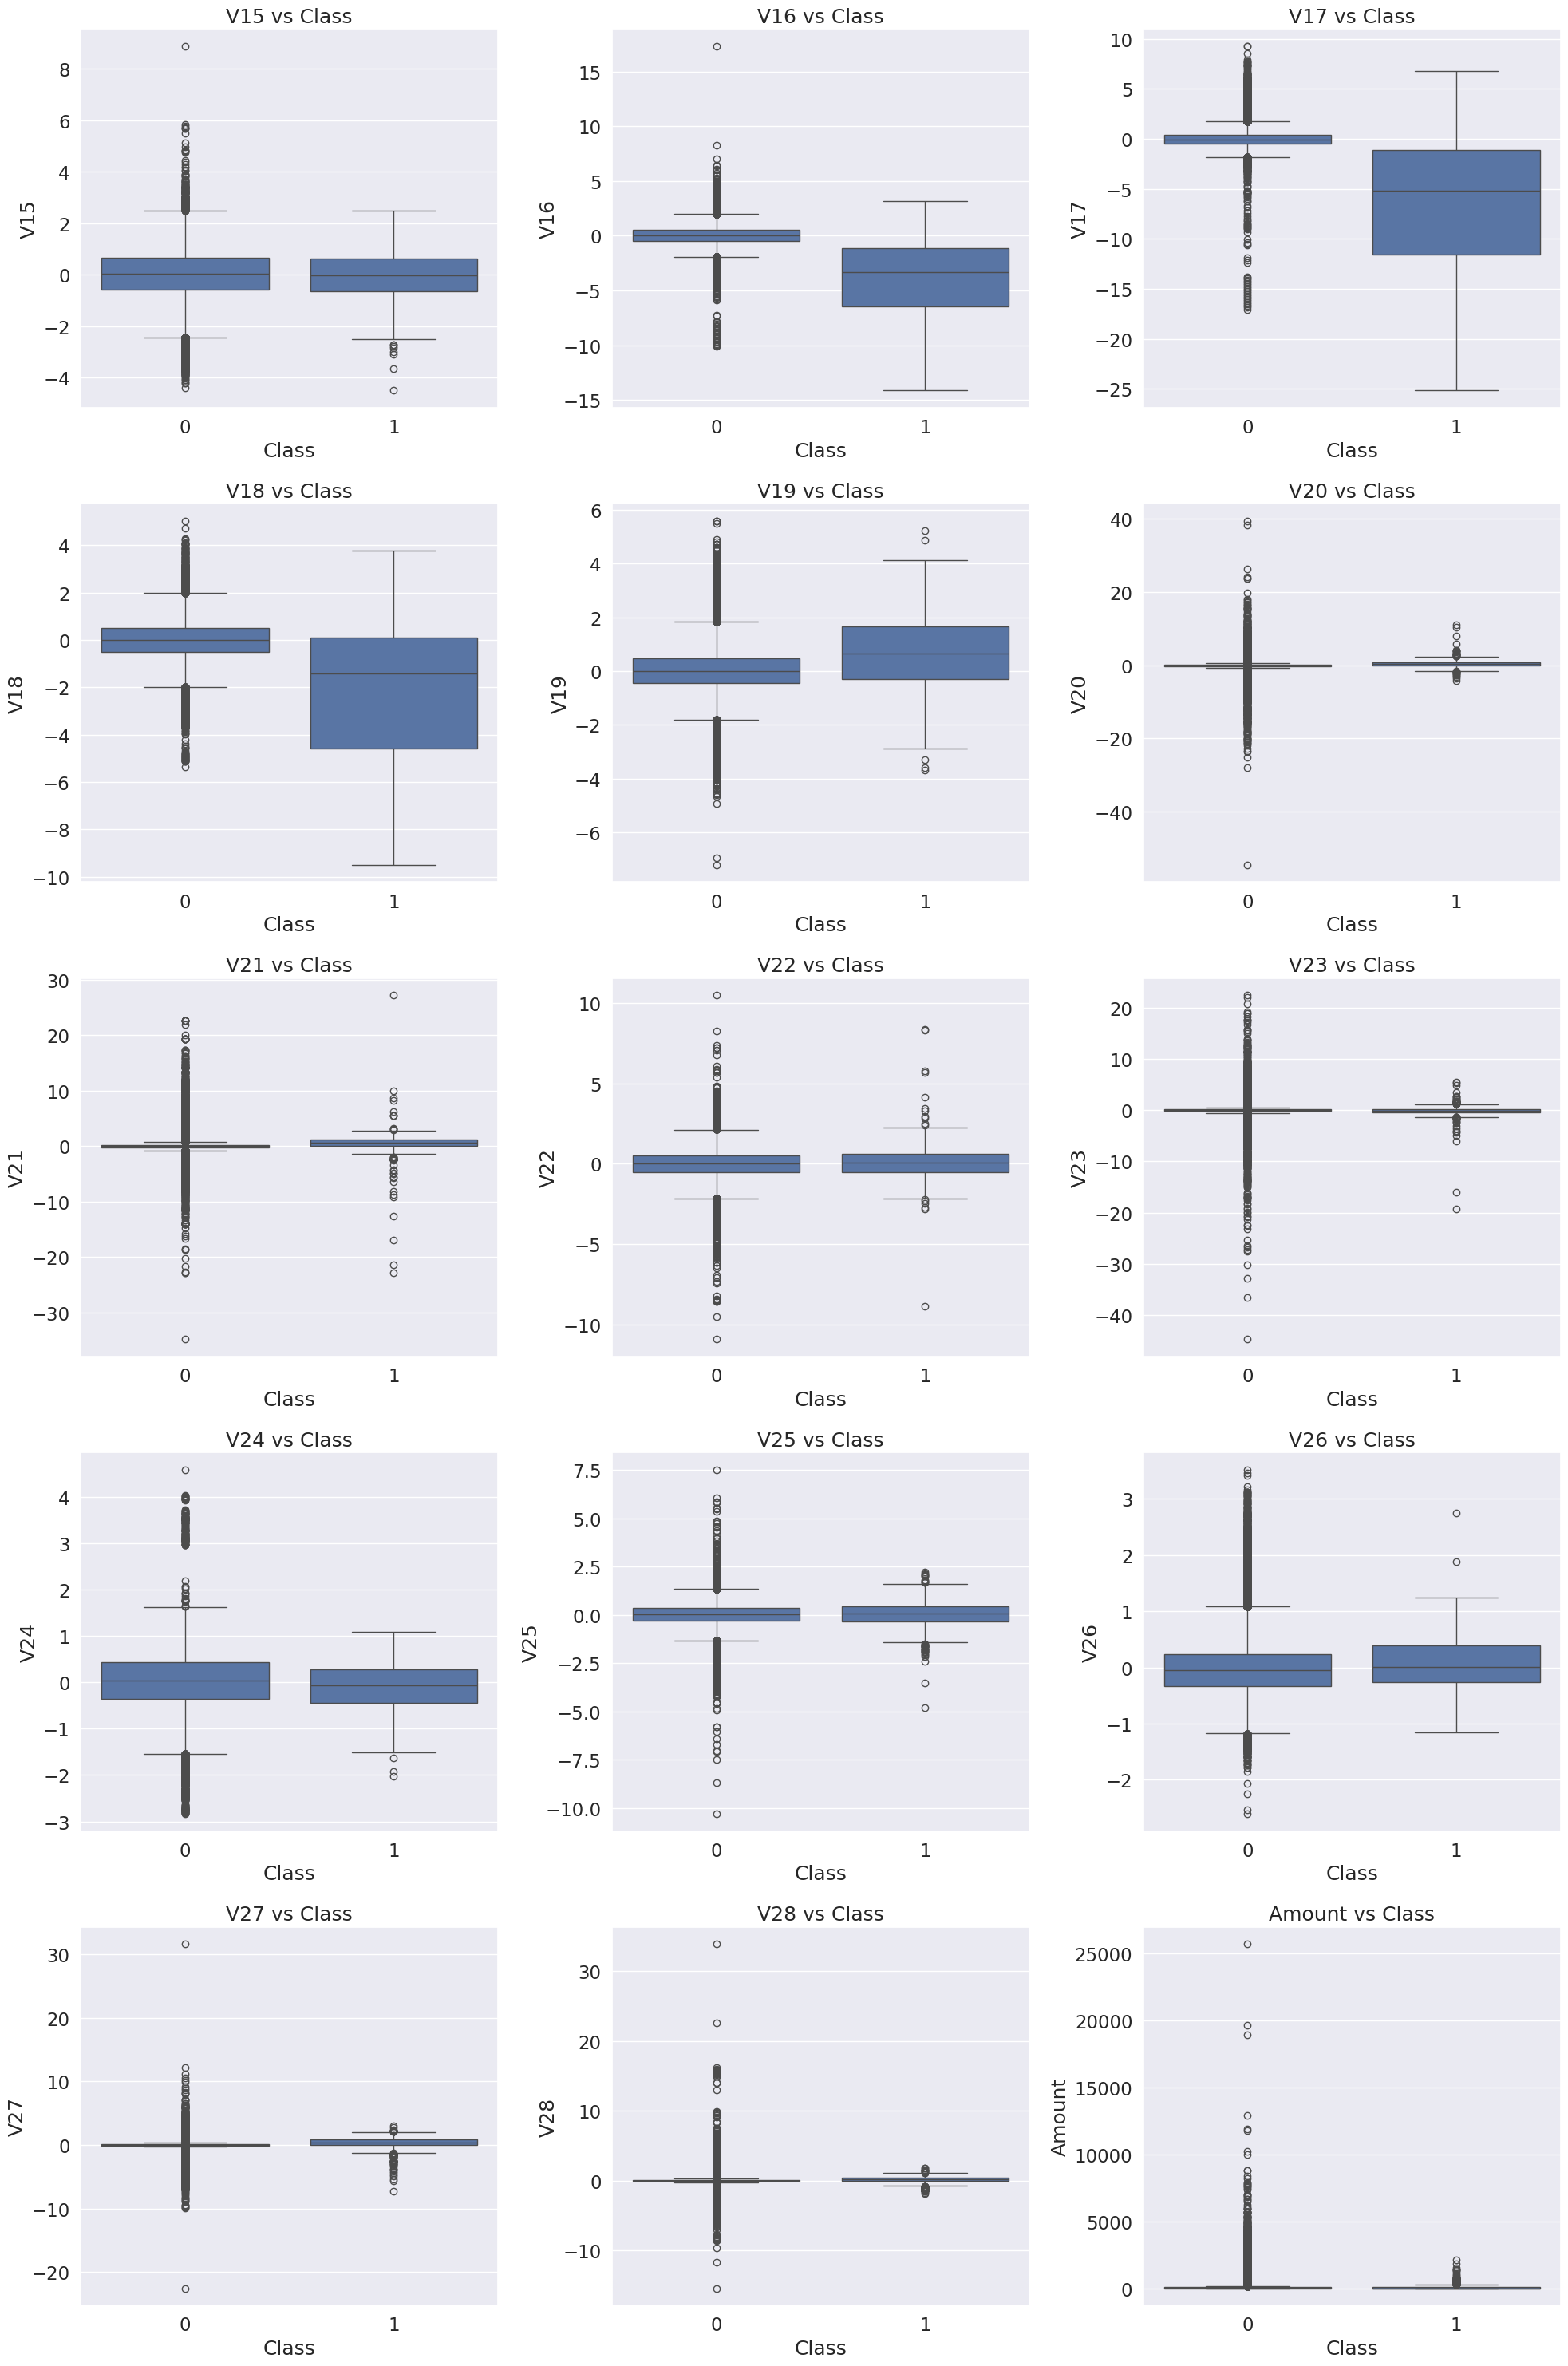

In [24]:
plt.figure(figsize=(20, 30))
for i, feature in enumerate(second_half, start=1):
    plt.subplot(5, 3, i)  
    sns.boxplot(x="Class", y=feature, data=df)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Class")
plt.tight_layout()
plt.show()

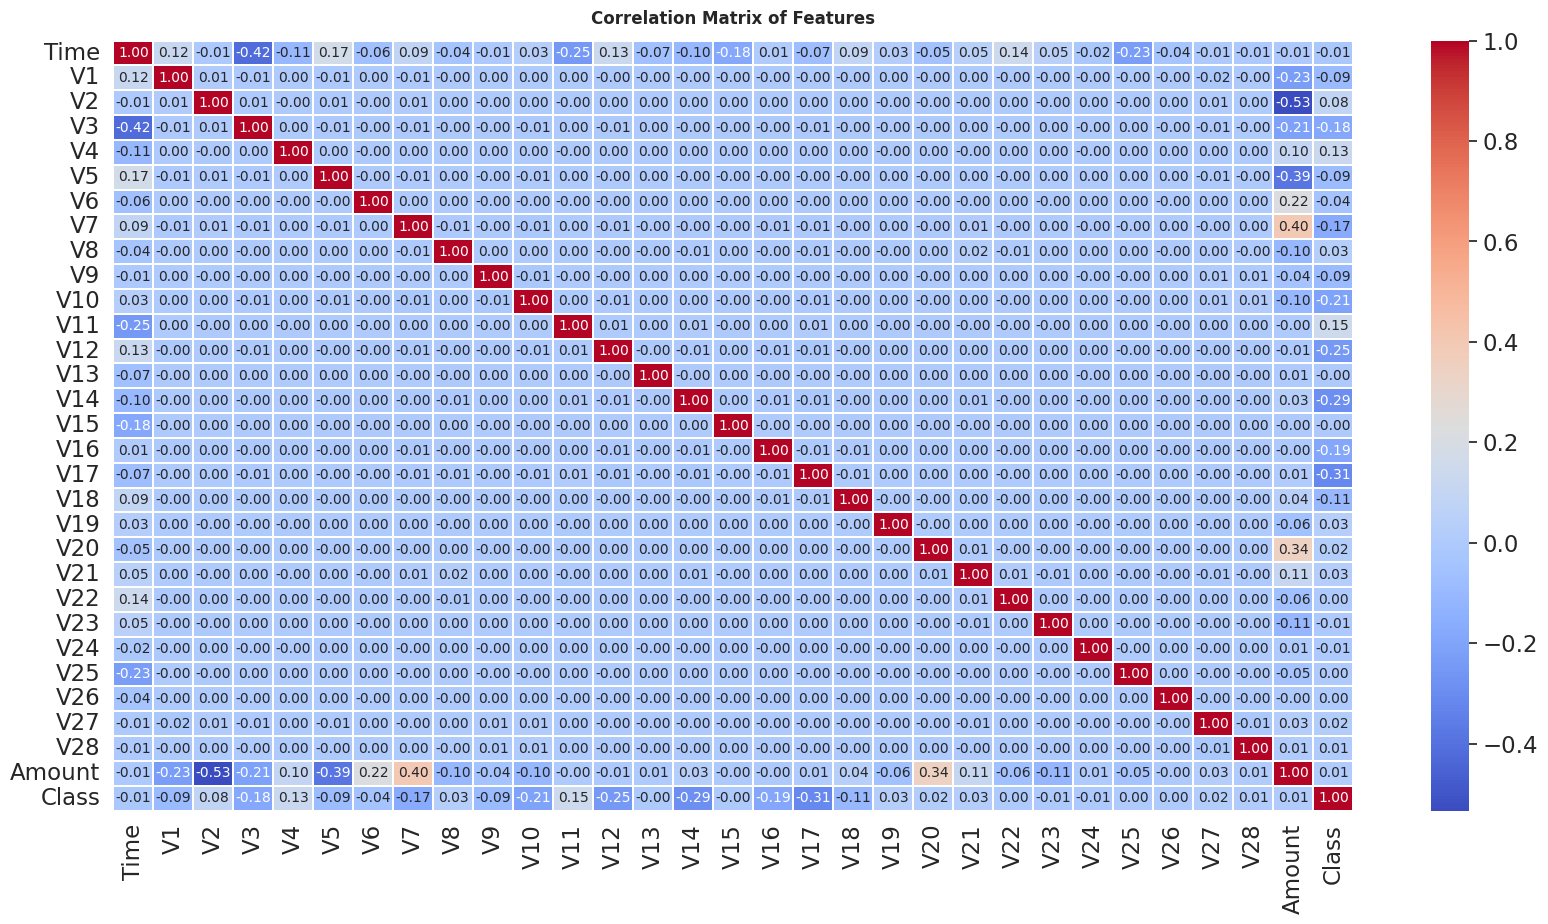

In [25]:
corr = df.corr()
plt.figure(figsize = (20, 10))
sns.heatmap(corr, annot=True, fmt='.2f', lw=0.2,cmap = 'coolwarm', annot_kws={'size': 10})
plt.title('Correlation Matrix of Features',fontweight = 'black', fontsize = 12, pad = 12)
plt.show()

## **⚙ Data Preprocessing**

In [26]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [27]:
X.shape, y.shape

((283726, 30), (283726,))

**Train Test Split**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

In [29]:
time_28V_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler())
])

amount_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('log_transfrom', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('time_28V', time_28V_pipeline, [col for col  in X.columns if col != 'Amount']),
    ('amount', amount_pipeline, ['Amount'])
])

In [30]:
x_train_processed = preprocessor.fit_transform(X_train)
x_test_processed = preprocessor.transform(X_test)

**Handle Inbalance Data ( Over Sampling - SMOTE )**

In [31]:
smote = SMOTE(random_state = 42)
X_res, y_res = smote.fit_resample(x_train_processed, y_train)

In [32]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_res.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


In [33]:
print(X_res.shape)
print(y_res.shape)

print(x_train_processed.shape)
print(y_train.shape)

(453204, 30)
(453204,)
(226980, 30)
(226980,)


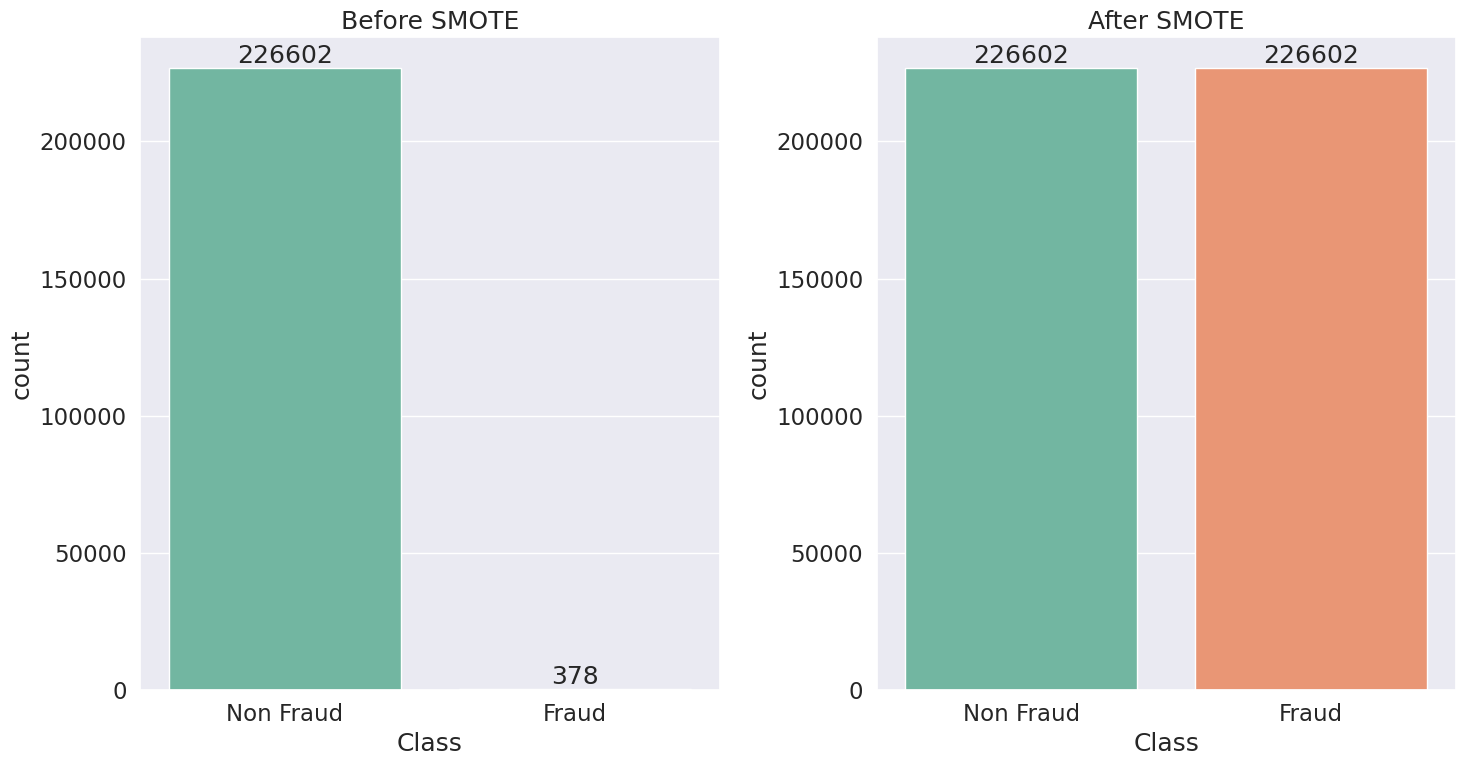

In [34]:
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
ax = sns.countplot(x=y_train, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

plt.title("Before SMOTE")
plt.xticks([0,1], ["Non Fraud", "Fraud"])


plt.subplot(1,2,2)
ax = sns.countplot(x=y_res, palette="Set2")
for container in ax.containers:
    ax.bar_label(container)

plt.title("After SMOTE")
plt.xticks([0,1], ["Non Fraud", "Fraud"])

plt.tight_layout()
plt.show()

## **🚂 Train Model**

In [35]:
log_model = LogisticRegression(C = 0.001, class_weight = 'balanced', random_state = 42, n_jobs = -1)
log_model.fit(X_res, y_res)

LogisticRegression(C=0.001, class_weight='balanced', n_jobs=-1, random_state=42)

In [36]:
y_valid_pred = cross_val_predict(log_model, X_res, y_res, cv=5, method='predict', n_jobs =-1)

print("Precistion", precision_score(y_res, y_valid_pred))
print("Recall", recall_score(y_res, y_valid_pred))
print("F1-Score", f1_score(y_res, y_valid_pred))

Precistion 0.975367600262117
Recall 0.9130281286131632
F1-Score 0.9431688932145943


In [37]:
y_pred = log_model.predict(x_test_processed)
y_prob = log_model.predict_proba(x_test_processed)[:,1]

In [38]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



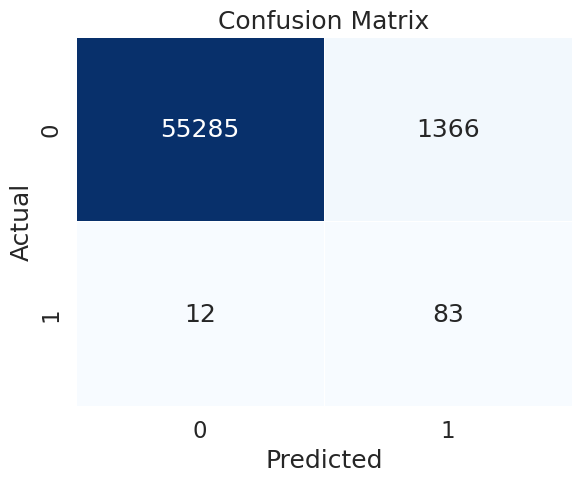

In [39]:
# Create a confusion matrix
con_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
sns.heatmap(con_matrix, annot=True, fmt='1.0f', cmap='Blues', lw=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
rf_model = RandomForestClassifier(n_estimators = 50, max_depth = 25, class_weight = 'balanced', random_state = 42, n_jobs = -1)
rf_model.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', max_depth=25, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [42]:
y_valid_pred = cross_val_predict(rf_model, X_res, y_res, cv=5, method='predict', n_jobs =-1)

print("Precistion", precision_score(y_res, y_valid_pred))
print("Recall", recall_score(y_res, y_valid_pred))
print("F1-Score", f1_score(y_res, y_valid_pred))

Precistion 0.9997485209058542
Recall 1.0
F1-Score 0.9998742446405051


In [43]:
y_pred_rf = rf_model.predict(x_test_processed)
y_prob_rf = rf_model.predict_proba(x_test_processed)[:,1]

In [44]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



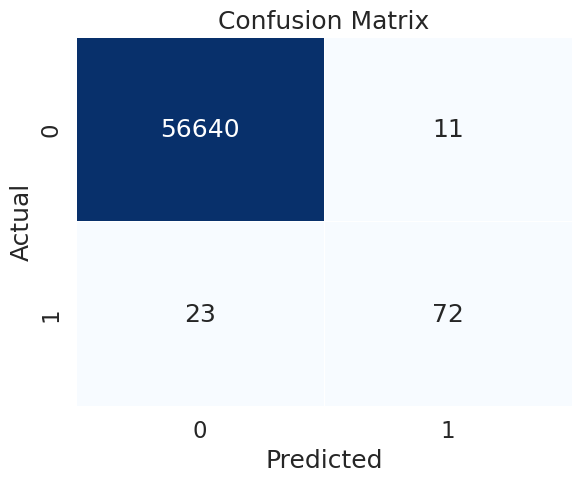

In [45]:
# Create a confusion matrix
con_matrix = confusion_matrix(y_test, y_pred_rf)

# Visualize the confusion matrix with a heatmap
sns.heatmap(con_matrix, annot=True, fmt='1.0f', cmap='Blues', lw=.5, cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **🏆 Comparing Results**

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.975716   0.057281  0.873684  0.107513  0.960326
1        Random Forest  0.999401   0.867470  0.757895  0.808989  0.962407


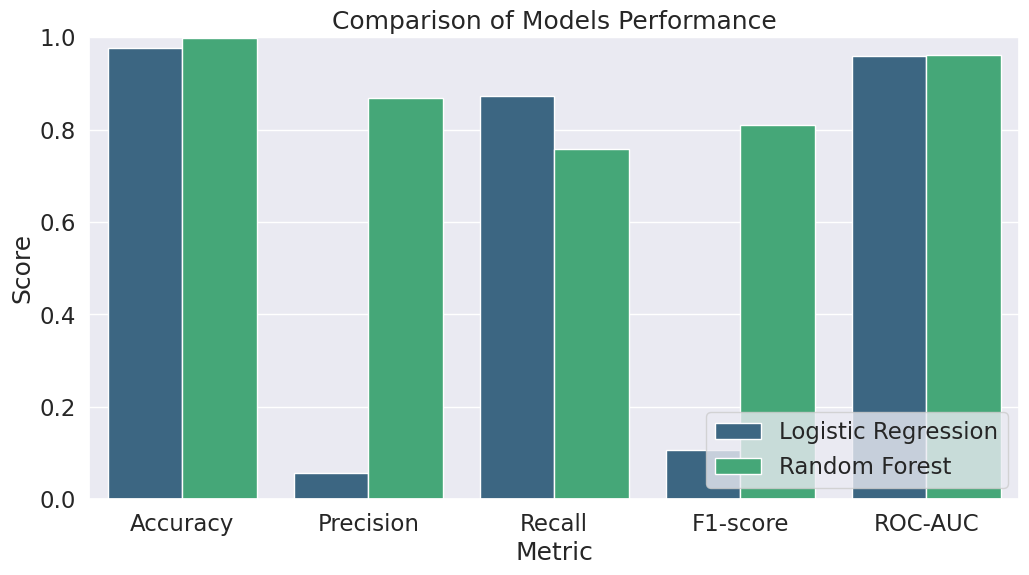

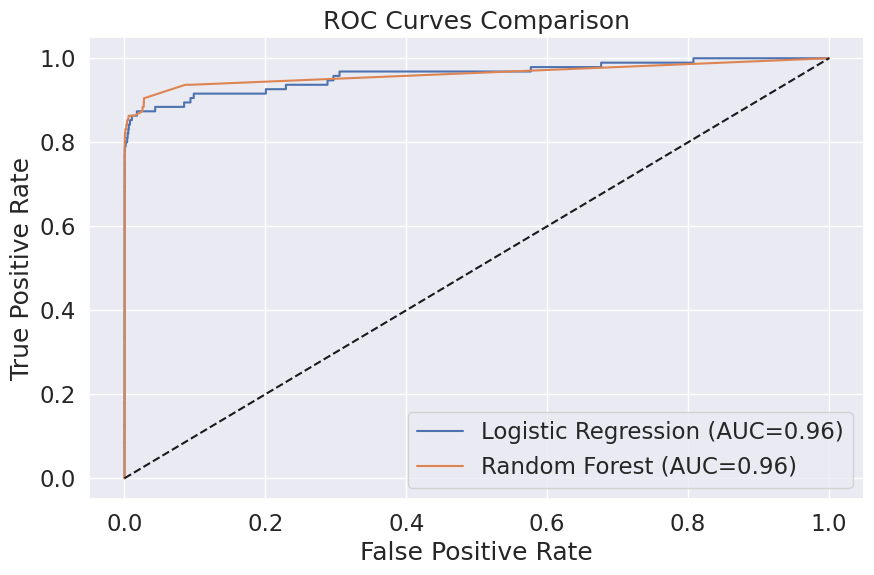

In [46]:
models = {
    "Logistic Regression": (y_test, y_pred, y_prob),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf),
}

results = []

for name, (yt, yp, ypr) in models.items():
    report = classification_report(yt, yp, output_dict=True)
    auc = roc_auc_score(yt, ypr)
    acc = accuracy_score(yt, yp)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": auc
    })

df_results = pd.DataFrame(results)
print(df_results)

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars="Model", value_vars=metrics, 
                            var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette = 'viridis')
plt.title("Comparison of Models Performance")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

# -------------------------------
# 3- رسم ROC Curves
# -------------------------------
plt.figure(figsize=(10, 6))

for name, (yt, yp, ypr) in models.items():
    fpr, tpr, _ = roc_curve(yt, ypr)
    auc = roc_auc_score(yt, ypr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # خط التوزيع العشوائي
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()